In [1]:
!pip install geopandas matplotlib
!pip install geodatasets
!pip install rioxarray
!pip install openpyxl
!pip install selenium webdriver-manager
!pip install fiona

!pip install netCDF4
!pip install seaborn
!pip install scipy
!pip install pygam

In [2]:
import copernicusmarine
from netCDF4 import Dataset, num2date
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.dates as mdates
import os
import xarray as xr
import rioxarray as rxr
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime
import glob
from scipy import stats
from scipy.stats import linregress
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
from shapely.geometry import MultiPolygon
from shapely import wkb
import pandas as pd
import re
import time
import json
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from scipy import stats
import geopandas as gpd
import rioxarray
import fiona
from pygam import LinearGAM, s, f
import numpy as np

The purpose of this file is to find correlation between the satellite data, the river chemistry data, and the atmospheric data.

Will have Kd490, Chl-a, SPM, SST, and CDOM satellite data with a coastal buffer (going to use 0.1 deg and 0.05 deg to see if there is a difference)
Will have river chemistry data for constituents of interest for ROI, going to use a buffer to find those close to the coast
Will have atmospheric (wind, direction, and precipitation data) for 7 stations around ireland to see offshore vs onshore wind and rain events

Notes: Need to **reproject everything to a meter based system** to have the buffer in kilometers and consistent as it gets further north

# Ireland Buffer

In [6]:
island_gdf = gpd.read_file("thesis_data/island_boundary.gpkg")

In [7]:
print(island_gdf.crs)

EPSG:4326


In [8]:
layers = fiona.listlayers("thesis_data/island_boundary.gpkg")
print(f"Available layers: {layers}")

Available layers: ['island_boundary']


Need to pull out ROI, as I don't have river data for NI

In [9]:
print(island_gdf.columns)

Index(['GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')


In [10]:
print(island_gdf['NAME_1'].unique())
print(island_gdf['COUNTRY'].unique())

[None 'Northern Ireland']
['Ireland' 'United Kingdom']


In [11]:
ireland = island_gdf[island_gdf['NAME_1'] != 'Northern Ireland']

In [12]:
#ireland.plot()

In [13]:
ireland.to_file("republic_ireland_land_boundary.gpkg", driver="GPKG")

In [14]:
ireland = gpd.read_file("thesis_data/republic_ireland_land_boundary.gpkg")

<Axes: >

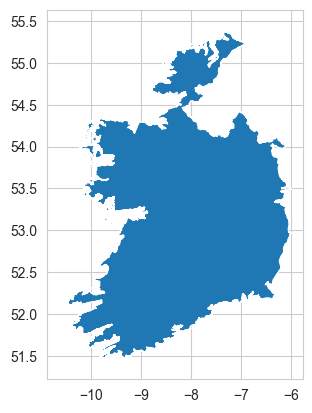

In [15]:
ireland.plot()

In [16]:
ireland_3035= ireland.to_crs(epsg=3035)
## reproject to EPSG:3035 ETRS89-extended / LAEA Europe) is the official Projected Coordinate Reference System recommended by the European Commission for mapping, statistical analysis, and spatial modeling across the European Union
## its a meter based system

In [17]:
island_3035 = island_gdf.to_crs(epsg=3035)

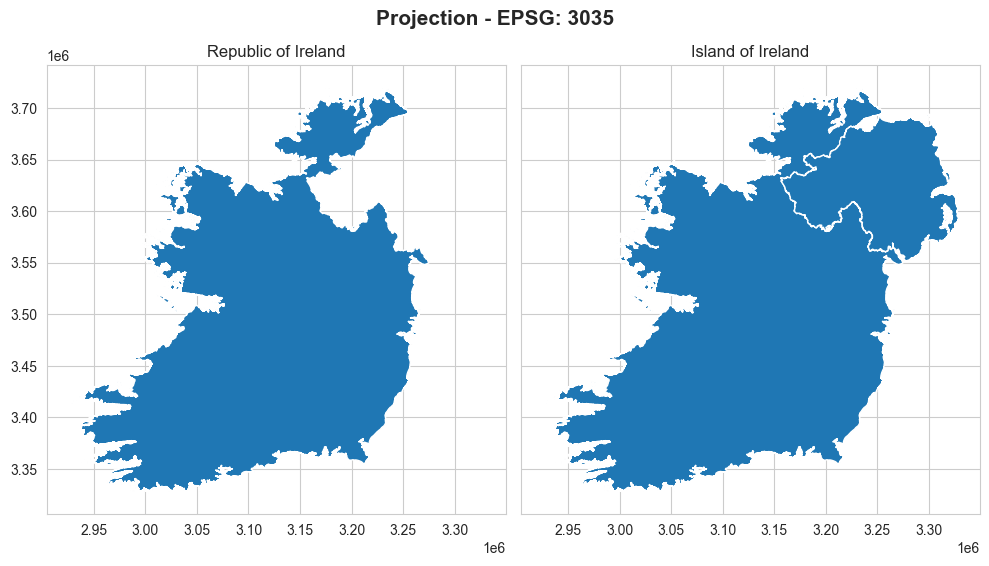

In [18]:
fig, ax = plt.subplots(1,2, figsize=(10,5.5), sharey=True, sharex=True)

ax1 = ireland_3035.plot(ax=ax[0])
ax1.set_title('Republic of Ireland')

ax2 = island_3035.plot(ax=ax[1])
ax2.set_title('Island of Ireland')

fig.suptitle('Projection - EPSG: 3035', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

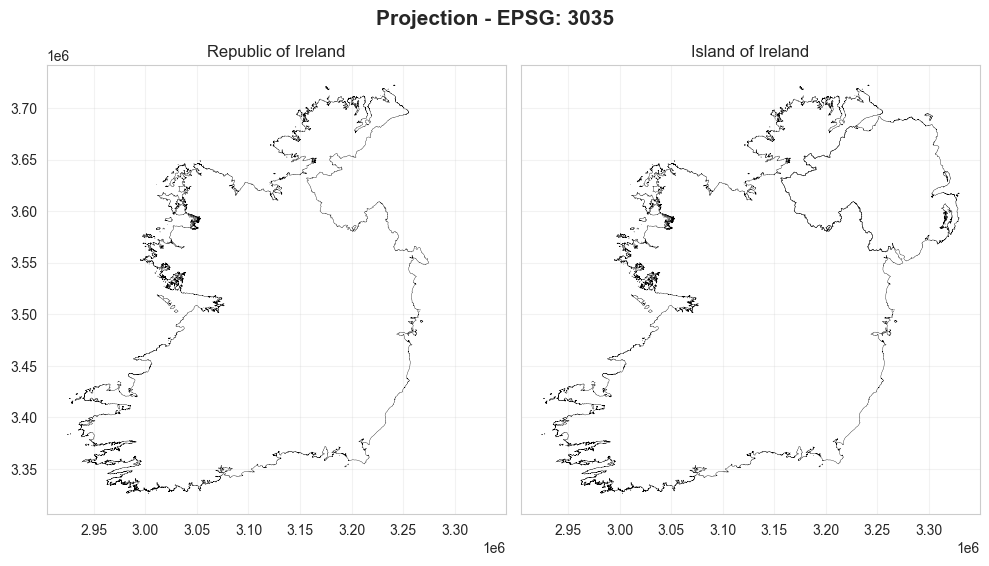

In [19]:
fig, ax = plt.subplots(1,2, figsize=(10,5.5), sharey=True, sharex=True)

ax1 = ireland_3035.boundary.plot(ax=ax[0], linewidth=0.25, edgecolor='k')
ax1.set_title('Republic of Ireland')
ax1.grid(alpha=0.25)

ax2 = island_3035.boundary.plot(ax=ax[1],linewidth=0.25, edgecolor='k')
ax2.set_title('Island of Ireland')
ax2.grid(alpha=0.25)

fig.suptitle('Projection - EPSG: 3035', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Atmospheric Data

In [20]:
atmo = gpd.read_parquet('atmo_stage3_projected.parquet')

# Satellite Data

## Kd490

In [3]:
file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/*.nc'))
all_ds = xr.open_mfdataset(file_list, concat_dim='time', combine='nested')
## combine all the files into one, massive DataSet so that we can do comparisons over years


In [4]:
weekly_kd490 = all_ds['KD490'].resample(time='1W').mean()
monthly_kd490 = all_ds['KD490'].resample(time='1ME').mean()

In [5]:
weekly_kd490

<xarray.DataArray 'KD490' (time: 1462, latitude: 1056, longitude: 1248)> Size: 8GB
dask.array<stack, shape=(1462, 1056, 1248), dtype=float32, chunksize=(1, 1056, 1248), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 12kB 1997-09-07 1997-09-14 ... 2025-09-07
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Attributes:
    long_name:      Diffuse attenuation coefficient - Mean of the binned pixels
    valid_min:      0.0
    standard_name:  volume_attenuation_coefficient_of_downwelling_radiative_f...
    units:          m-1
    valid_max:      1000.0

In [6]:
## need to write it to 4326, and then reproject to epsg 3035
weekly_kd490_4326 = weekly_kd490.rio.write_crs("EPSG:4326")
kd_3035 = weekly_kd490_4326.rio.reproject('EPSG:3035')
#weekly_kd490_3035

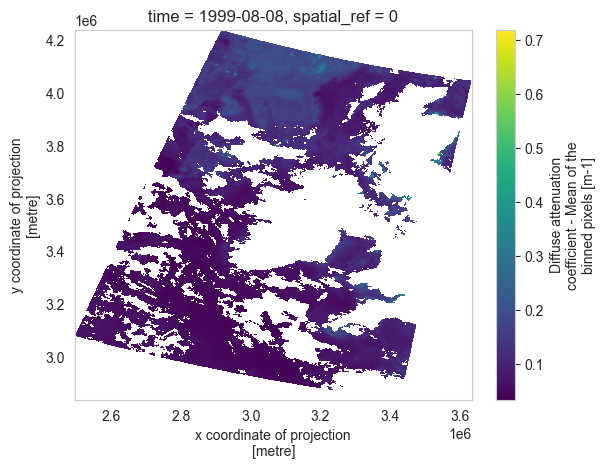

In [25]:
# Make sure they match still
kd_3035[100].plot()

In [26]:
#weekly_kd490[100].plot()

## Load in an Reproject Other Variables to Match KD490

In [7]:
chla_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/chlorophyll/*.nc'))
chla_ds = xr.open_mfdataset(chla_file_list, concat_dim='time', combine='nested')

weekly_chla = chla_ds['CHL'].resample(time='1W').mean()
monthly_chla = chla_ds['CHL'].resample(time='1ME').mean()

chla_3035  = weekly_chla.rio.write_crs("EPSG:4326").rio.reproject_match(kd_3035)

In [8]:
cdom_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/CDOM/*.nc'))
cdom_ds = xr.open_mfdataset(cdom_file_list, concat_dim='time', combine='nested')

weekly_cdom = cdom_ds['CDM'].resample(time='1W').mean(skipna=True)
monthly_cdom = cdom_ds['CDM'].resample(time='1ME').mean(skipna=True)

cdom_3035  = weekly_cdom.rio.write_crs("EPSG:4326").rio.reproject_match(kd_3035)

In [9]:
spm_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/SPM/*.nc'))
spm_ds = xr.open_mfdataset(spm_file_list, concat_dim='time', combine='nested')

weekly_spm = spm_ds['SPM'].resample(time='1W').mean(skipna=True)
monthly_spm = spm_ds['SPM'].resample(time='1ME').mean(skipna=True)

spm_3035  = weekly_spm.rio.write_crs("EPSG:4326").rio.reproject_match(kd_3035)

In [10]:
sst_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/SST2/*.nc'))
sst_ds = xr.open_mfdataset(sst_file_list, concat_dim='time', combine='nested')

weekly_sst = sst_ds['analysed_sst'].resample(time='1W').mean()
monthly_sst = sst_ds['analysed_sst'].resample(time='1ME').mean()

sst_3035  = weekly_sst.rio.write_crs("EPSG:4326").rio.reproject_match(kd_3035)

In [11]:
# Combine into a unified dataset
satellite_ds = xr.Dataset({
    'kd490': kd_3035,
    'chl_a': chla_3035,
    'spm': spm_3035,
    'sst': sst_3035,
    'cdom': cdom_3035
})

# Verify that Dask chunking is still intact
print(satellite_ds)

<xarray.Dataset> Size: 67GB
Dimensions:      (x: 1247, y: 1535, time: 1462)
Coordinates:
  * x            (x) float64 10kB 2.496e+06 2.497e+06 ... 3.633e+06 3.633e+06
  * y            (y) float64 12kB 4.239e+06 4.238e+06 ... 2.839e+06 2.838e+06
  * time         (time) datetime64[ns] 12kB 1997-09-07 1997-09-14 ... 2025-09-07
    spatial_ref  int64 8B 0
Data variables:
    kd490        (time, y, x) float32 11GB nan nan nan nan ... nan nan nan nan
    chl_a        (time, y, x) float32 11GB nan nan nan nan ... nan nan nan nan
    spm          (time, y, x) float32 11GB nan nan nan nan ... nan nan nan nan
    sst          (time, y, x) float64 22GB nan nan nan nan ... nan nan nan nan
    cdom         (time, y, x) float32 11GB nan nan nan nan ... nan nan nan nan


In [32]:
print(type(satellite_ds['kd490'].data))

<class 'numpy.ndarray'>


In [12]:
satellite_ds = satellite_ds.chunk({'time': 52, 'x': -1, 'y': -1})

# River Data

In [34]:
river_df = pd.read_parquet('coastal_river_data_short.parquet')

In [35]:
## need to get the geometry back in
roi_shp = gpd.read_file("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EPA_River_Estuary_Data/WFD Shapefile/WFD_RiverWaterbodies_08042026/WFD_RiverWaterbodiesActive_Cycle3.shp")
print("Current map projection: ", roi_shp.crs)
print(roi_shp.head())

C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(


Current map projection:  EPSG:29902
             EU_CD                    NAME         MS_CD REGION_CD   INS_WHEN  \
0  IE_SH_25S020700  SILVER (KILCORMAC)_050  SH_25S020700        17 2014-11-14   
1  IE_SH_25S030010  SILVER (TULLAMORE)_010  SH_25S030010        17 2014-11-14   
2  IE_SH_25S030100  SILVER (TULLAMORE)_020  SH_25S030100        17 2014-11-14   
3  IE_SH_25S030300  SILVER (TULLAMORE)_030  SH_25S030300        17 2014-11-14   
4  IE_SH_25S030500  SILVER (TULLAMORE)_040  SH_25S030500        17 2014-11-14   

       INS_BY          BASIN_CD        LAT       LON   LENGTHKM  ...  DIST_CD  \
0  AME RG EPA  155b Shannon Lwr  53.204961 -7.823378  16.767352  ...  Shannon   
1  AME RG EPA  155b Shannon Lwr  53.337071 -7.394927   8.932399  ...  Shannon   
2  AME RG EPA  155b Shannon Lwr  53.325244 -7.425840  19.020849  ...  Shannon   
3  AME RG EPA  155b Shannon Lwr  53.300455 -7.529738   6.791169  ...  Shannon   
4  AME RG EPA  155b Shannon Lwr  53.308626 -7.595396   6.541576  ...  Sh

In [36]:
roi_shp_short = roi_shp[['EU_CD','geometry']]
roi_shp_short = roi_shp_short.rename(columns={'EU_CD':'WaterbodyCode'})
roi_shp_short = roi_shp_short.to_crs("EPSG: 3035")
## need it to be in 3035 projection first

In [37]:
unique_rivers_gdf = roi_shp_short[roi_shp_short['WaterbodyCode'].isin(river_df['WaterbodyCode'])].copy()
unique_rivers_gdf
## just use this one as it is shorter for now, can add to river_df later

,WaterbodyCode,geometry
127,IE_EA_08B310940,"MULTILINESTRING ((3263885.954 3498550.893, 326..."
148,IE_EA_08P030930,"MULTILINESTRING ((3258025.352 3497642.131, 325..."
154,IE_EA_08W010610,"MULTILINESTRING ((3253166.122 3491839.836, 325..."
161,IE_EA_09B130400,"MULTILINESTRING ((3250925.25 3472631.412, 3250..."
165,IE_EA_09C020500,"MULTILINESTRING ((3239691.715 3478713.992, 323..."
...,...,...
3093,IE_WE_35D120800,"MULTILINESTRING ((3132136.429 3622960.052, 313..."
3101,IE_WE_35F010300,"MULTILINESTRING ((3100060.81 3618902.938, 3100..."
3114,IE_WE_35M540870,"MULTILINESTRING ((3138972.878 3633873.737, 313..."
3134,IE_WE_35W010300,"MULTILINESTRING ((3133367.407 3616950.979, 313..."


In [38]:
unique_rivers_gdf.crs

<Projected CRS: EPSG: 3035>
Name: ETRS89-extended / LAEA Europe
Axis Info [cartesian]:
- Y[north]: Northing (metre)
- X[east]: Easting (metre)
Area of Use:
- name: Europe - European Union (EU) countries and candidates. Europe - onshore and offshore: Albania; Andorra; Austria; Belgium; Bosnia and Herzegovina; Bulgaria; Croatia; Cyprus; Czechia; Denmark; Estonia; Faroe Islands; Finland; France; Germany; Gibraltar; Greece; Hungary; Iceland; Ireland; Italy; Kosovo; Latvia; Liechtenstein; Lithuania; Luxembourg; Malta; Monaco; Montenegro; Netherlands; North Macedonia; Norway including Svalbard and Jan Mayen; Poland; Portugal including Madeira and Azores; Romania; San Marino; Serbia; Slovakia; Slovenia; Spain including Canary Islands; Sweden; Switzerland; Türkiye (Turkey); United Kingdom (UK) including Channel Islands and Isle of Man; Vatican City State.
- bounds: (-35.58, 24.6, 44.83, 84.73)
Coordinate Operation:
- name: Europe Equal Area 2001
- method: Lambert Azimuthal Equal Area
Datum: Eu

In [39]:
coast_boundary_geom = island_3035.union_all().boundary

In [40]:
## use this to extract the endpoints
def extract_coastal_endpoint(river_geometry, coast_geometry):
    """
    Takes a MultiLineString or LineString geometry, extracts all its constituent
    vertices, and returns the single Point closest to the coastline.
    """
    if river_geometry is None or river_geometry.is_empty:
        return None

    # Extract every single unique vertex (coordinate pair) from the river geometry
    if river_geometry.geom_type == 'MultiLineString':
        vertices = []
        for line in river_geometry.geoms:
            vertices.extend(list(line.coords))
    else:
        vertices = list(river_geometry.coords)

    # Remove duplicate coordinates to speed up the distance metrics
    unique_vertices = list(set(vertices))

    # Convert coordinate tuples to actual Shapely Point objects
    points = [Point(coords) for coords in unique_vertices]

    # Find which of these river vertices is physically closest to the coast line boundary
    closest_point = min(points, key=lambda p: p.distance(coast_geometry))

    return closest_point

# 5. Extract the mouth point for each river using your EPSG:3035 coast line geometry
# (Assuming 'coast_geom' is your Ireland outline boundary converted to EPSG:3035)
unique_rivers_gdf['mouth_point'] = unique_rivers_gdf['geometry'].apply(
    lambda geom: extract_coastal_endpoint(geom, coast_boundary_geom)
)

# 6. Break the points down into explicit X and Y coordinate columns (in EPSG:3035 meters)
unique_rivers_gdf['x_3035'] = unique_rivers_gdf['mouth_point'].apply(lambda p: p.x if p else None)
unique_rivers_gdf['y_3035'] = unique_rivers_gdf['mouth_point'].apply(lambda p: p.y if p else None)

In [41]:
unique_rivers_gdf

,WaterbodyCode,geometry,mouth_point,x_3035,y_3035
127,IE_EA_08B310940,"MULTILINESTRING ((3263885.954 3498550.893, 326...",POINT (3264415.451 3498659.253),3.264415e+06,3.498659e+06
148,IE_EA_08P030930,"MULTILINESTRING ((3258025.352 3497642.131, 325...",POINT (3258162.763 3496662.898),3.258163e+06,3.496663e+06
154,IE_EA_08W010610,"MULTILINESTRING ((3253166.122 3491839.836, 325...",POINT (3254766.593 3493557.848),3.254767e+06,3.493558e+06
161,IE_EA_09B130400,"MULTILINESTRING ((3250925.25 3472631.412, 3250...",POINT (3251639.421 3476167.369),3.251639e+06,3.476167e+06
165,IE_EA_09C020500,"MULTILINESTRING ((3239691.715 3478713.992, 323...",POINT (3243889.091 3480525.303),3.243889e+06,3.480525e+06
...,...,...,...,...,...
3093,IE_WE_35D120800,"MULTILINESTRING ((3132136.429 3622960.052, 313...",POINT (3130318.259 3623856.591),3.130318e+06,3.623857e+06
3101,IE_WE_35F010300,"MULTILINESTRING ((3100060.81 3618902.938, 3100...",POINT (3099991.999 3626858.759),3.099992e+06,3.626859e+06
3114,IE_WE_35M540870,"MULTILINESTRING ((3138972.878 3633873.737, 313...",POINT (3139586.965 3634926.373),3.139587e+06,3.634926e+06
3134,IE_WE_35W010300,"MULTILINESTRING ((3133367.407 3616950.979, 313...",POINT (3132529.776 3617190.69),3.132530e+06,3.617191e+06


In [42]:
## need to make a donut ring of 1km to 3km outside of the river mouth to eliminate land contamination in the value of Kd490 etc
land_geometry = island_3035.union_all()

# 2. Let's build the marine donut buffer for each unique river mouth
# We run this on the unique_rivers_gdf table we created in the last step
marine_buffers = []

for _, row in unique_rivers_gdf.iterrows():
    river_id = row['WaterbodyCode']
    mouth = row['mouth_point'] # This is the Shapely Point object we found

    if mouth is None:
        continue

    # Create the outer 3 km circle
    outer_circle = mouth.buffer(3000)

    # Create the inner 1 km circle (to push out past the mixed shoreline pixels)
    inner_circle = mouth.buffer(1000)

    # Subtract the inner circle from the outer circle to make the donut ring
    donut_ring = outer_circle.difference(inner_circle)

    # Subtract the land mass from the donut ring so it ONLY covers the marine side
    pure_marine_buffer = donut_ring.difference(land_geometry)

    # Keep track of it
    marine_buffers.append({
        'WaterbodyCode': river_id,
        'geometry': pure_marine_buffer
    })

# 3. Convert our list into a clean GeoDataFrame sharing our EPSG:3035 CRS
marine_buffers_gdf = gpd.GeoDataFrame(marine_buffers, crs="EPSG:3035")

# Combine Satellite and River Data

In [83]:
river_time_series_list = []

for _, row in marine_buffers_gdf.iterrows():
    river_id = row['WaterbodyCode']
    buffer_geom = row['geometry']

    if buffer_geom.is_empty:
        continue

    # Extract bounding box
    minx, miny, maxx, maxy = buffer_geom.bounds

    # --- SAFE SLICING TO HANDLE ASCENDING/DESCENDING COORDINATES ---
    # We sort the slice limits dynamically so xarray never gets a zero-length result
    x_slice = slice(min(minx, maxx) - 1000, max(minx, maxx) + 1000)
    y_slice = slice(min(miny, maxy) - 1000, max(miny, maxy) + 1000)

    neighborhood_ds = satellite_ds.sel(x=x_slice, y=y_slice)

    # Alternate fall-back: If the axes order still returns empty coordinates, flip the Y slice orientation
    if len(neighborhood_ds.x) == 0 or len(neighborhood_ds.y) == 0:
        y_slice_flipped = slice(max(miny, maxy) + 1000, min(miny, maxy) - 1000)
        neighborhood_ds = satellite_ds.sel(x=x_slice, y=y_slice_flipped)

    # Final check to verify we captured the pixel cluster
    if len(neighborhood_ds.x) == 0 or len(neighborhood_ds.y) == 0:
        continue

    # 1. Clip down to the land-free marine donut mask geometry
    clipped_ds = neighborhood_ds.rio.clip([buffer_geom], crs="EPSG:3035", all_touched=True)

    # 2. Take the spatial mean over the local pixel block
    spatial_mean_ds = clipped_ds.mean(dim=['x', 'y'], skipna=True)

    # 3. Safely calculate the 1D time-series data table
    df = spatial_mean_ds.to_dataframe().reset_index()
    df['WaterbodyCode'] = river_id

    # --- THE FIX: Attach the geometry polygon to every row in this river's timeline ---
    df['geometry'] = buffer_geom

    river_time_series_list.append(df)

# Check if we successfully built the frames before combining
if len(river_time_series_list) > 0:
    # Combine the dataframes normally
    combined_df = pd.concat(river_time_series_list, ignore_index=True)

    # Convert the combined flat table into a structural GeoDataFrame
    satellite_time_series_df = gpd.GeoDataFrame(combined_df, geometry='geometry', crs="EPSG:3035")
    print(f"Success! Extracted spatial time series for {len(river_time_series_list)} stations.")
else:
    print("Error: The list is still empty. Check if coordinate scales match up.")

Success! Extracted spatial time series for 132 stations.


In [84]:
satellite_time_series_df

,time,spatial_ref,kd490,chl_a,spm,sst,cdom,WaterbodyCode,geometry
0,1997-09-07,0,NaN,NaN,NaN,288.323611,NaN,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
1,1997-09-14,0,NaN,NaN,NaN,288.208095,NaN,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
2,1997-09-21,0,NaN,NaN,NaN,287.938201,NaN,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
3,1997-09-28,0,0.203196,3.816583,18.000685,287.698466,0.116133,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
4,1997-10-05,0,NaN,NaN,NaN,287.502910,NaN,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
...,...,...,...,...,...,...,...,...,...
192979,2025-08-10,0,NaN,NaN,0.861111,NaN,NaN,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."
192980,2025-08-17,0,NaN,NaN,NaN,NaN,NaN,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."
192981,2025-08-24,0,NaN,NaN,NaN,NaN,NaN,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."
192982,2025-08-31,0,NaN,NaN,11.508750,NaN,2.603577,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."


In [85]:
river_weekly_df = river_df[river_df['SampleDate'].isin(satellite_time_series_df['time'])]

In [47]:
river_weekly_df.sort_values('SampleDate')

,SampleDate,WaterbodyCode,AnalyticalMethodGroup,interpolated_value
3260417,2007-01-14,IE_WE_32D010200,Nitrite_Methods,0.178482
3572448,2007-01-14,IE_WE_35F010300,Nitrite_Methods,0.178482
3249574,2007-01-14,IE_WE_32D010200,BOD - 5 days (Total),15.625977
3483896,2007-01-14,IE_WE_35D060200,Nitrite_Methods,0.178482
3320786,2007-01-14,IE_WE_32O030300,Ammonia_Methods,1.070893
...,...,...,...,...
1378934,2025-09-07,IE_NW_40A090780,Orthophosphate (as P) -filtered,13.091625
1382723,2025-09-07,IE_NW_40A090780,Suspended Solids,4162.500000
1385175,2025-09-07,IE_NW_40A090780,ortho-Phosphate_Methods,5.688911
1398927,2025-09-07,IE_NW_40B020400,BOD - 5 days (Total),35.539569


# Add Atmospheric Data into the Mix
Need to assign a weather station to each river

Need to find line tangent to the coast for onshore /offshore stuff

Want to use the 7 day rolling sum of rainfall, the weekly vector average  or maximum of the wind components

In [48]:
atmo.head(3)

,station,date,rain,mean_wind_speed_kt,high_ten_min_mean_kt,direction_highten_deg,highest_gust,latitude,longitude,rain_7d,geometry,x_3035,y_3035,wind_u,wind_v
0,ROCHES POINT,1955-12-01,9.1,11.5,18.0,170.0,24.0,51.793,-8.244,NaN,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06,-3.125667,1.772654e+01
1,ROCHES POINT,1955-12-02,0.9,12.1,23.0,210.0,32.0,51.793,-8.244,NaN,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06,11.500000,1.991858e+01
2,ROCHES POINT,1955-12-03,0.0,8.0,16.0,270.0,21.0,51.793,-8.244,NaN,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06,16.000000,2.939152e-15


In [49]:
unique_rivers_gdf.head(3)

,WaterbodyCode,geometry,mouth_point,x_3035,y_3035
127,IE_EA_08B310940,"MULTILINESTRING ((3263885.954 3498550.893, 326...",POINT (3264415.451 3498659.253),3.264415e+06,3.498659e+06
148,IE_EA_08P030930,"MULTILINESTRING ((3258025.352 3497642.131, 325...",POINT (3258162.763 3496662.898),3.258163e+06,3.496663e+06
154,IE_EA_08W010610,"MULTILINESTRING ((3253166.122 3491839.836, 325...",POINT (3254766.593 3493557.848),3.254767e+06,3.493558e+06


In [50]:
import pandas as pd
import numpy as np
from scipy.spatial import distance_matrix

# 1. Extract raw coordinate arrays from your geometries (guaranteed EPSG:3035 meters)
river_coords = np.array([(geom.x, geom.y) for geom in unique_rivers_gdf['mouth_point'] if geom is not None])
station_coords = np.array([(geom.x, geom.y) for geom in atmo['geometry']])

# Get the matching list of IDs
river_ids = [row['WaterbodyCode'] for _, row in unique_rivers_gdf.iterrows() if row['mouth_point'] is not None]
station_ids = list(atmo['station'])

# 2. Compute the entire distance grid in one millisecond block
dist_mat = distance_matrix(river_coords, station_coords)

# 3. Convert the distance matrix into a clean, flat dataframe
distance_df = pd.DataFrame(dist_mat, index=river_ids, columns=station_ids)
distance_df = distance_df.stack().reset_index()
distance_df.columns = ['WaterbodyCode', 'station', 'distance_to_station']

# 4. Sort and assign Primary (1) and Fallback (2) ranks
distance_df = distance_df.sort_values(by=['WaterbodyCode', 'distance_to_station'])
distance_df['rank'] = distance_df.groupby('WaterbodyCode').cumcount() + 1

# Extract the two priority levels
station_rank1 = distance_df[distance_df['rank'] == 1][['WaterbodyCode', 'station']].rename(columns={'station': 'primary_station'})
station_rank2 = distance_df[distance_df['rank'] == 2][['WaterbodyCode', 'station']].rename(columns={'station': 'fallback_station'})

# Combine them into your final structural map table
river_atmo_mapping = pd.merge(station_rank1, station_rank2, on='WaterbodyCode', how='left')

In [58]:
river_atmo_mapping

,WaterbodyCode,primary_station,fallback_station
0,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT
1,IE_EA_08P030930,DUBLIN AIRPORT,DUBLIN AIRPORT
2,IE_EA_08W010610,DUBLIN AIRPORT,DUBLIN AIRPORT
3,IE_EA_09B130400,DUBLIN AIRPORT,DUBLIN AIRPORT
4,IE_EA_09C020500,CASEMENT,CASEMENT
...,...,...,...
127,IE_WE_35D120800,BELMULLET,BELMULLET
128,IE_WE_35F010300,BELMULLET,BELMULLET
129,IE_WE_35M540870,BELMULLET,BELMULLET
130,IE_WE_35W010300,BELMULLET,BELMULLET


In [51]:
## now: getting the shore vectors:


shore_vectors = []

for _, row in unique_rivers_gdf.iterrows():
    river_id = row['WaterbodyCode']
    mouth = row['mouth_point']

    # Grab the corresponding land-free marine donut we built earlier
    marine_geom = marine_buffers_gdf[marine_buffers_gdf['WaterbodyCode'] == river_id]['geometry'].values[0]

    if mouth is None or marine_geom.is_empty:
        continue

    # Get the center of mass of the marine water area
    marine_center = marine_geom.centroid

    # Calculate the directional vector from the mouth point out into the sea
    dx = marine_center.x - mouth.x
    dy = marine_center.y - mouth.y

    # Normalize it to a "Unit Vector" (length of 1) so it only represents direction
    magnitude = np.sqrt(dx**2 + dy**2)
    ux = dx / magnitude  # Offshore X component (East-West alignment)
    uy = dy / magnitude  # Offshore Y component (North-South alignment)

    shore_vectors.append({
        'WaterbodyCode': river_id,
        'shore_normal_x': ux,  # Points offshore
        'shore_normal_y': uy   # Points offshore
    })

shore_vectors_df = pd.DataFrame(shore_vectors)

In [52]:
shore_vectors_df

,WaterbodyCode,shore_normal_x,shore_normal_y
0,IE_EA_08B310940,0.909613,-0.415457
1,IE_EA_08P030930,0.980667,-0.195682
2,IE_EA_08W010610,0.838790,-0.544454
3,IE_EA_09B130400,0.902642,0.430391
4,IE_EA_09C020500,0.992783,0.119925
...,...,...,...
127,IE_WE_35D120800,-0.747919,-0.663790
128,IE_WE_35F010300,0.316194,0.948695
129,IE_WE_35M540870,-0.026805,0.999641
130,IE_WE_35W010300,-0.865649,0.500651


In [53]:
## get the rolling values for atmospheric data

In [54]:
atmo.sort_values(by=['station','date'], inplace=True)

In [55]:
atmo['sumrain_7d'] = atmo.groupby('station')['rain'].transform(lambda x: x.rolling(7).sum())
atmo['meanwind_7d'] = atmo.groupby('station')['mean_wind_speed_kt'].transform(lambda x: x.rolling(7).mean())
atmo['maxburst_7d'] = atmo.groupby('station')['high_ten_min_mean_kt'].transform(lambda x: x.rolling(7).max())
atmo['mean_wind_u_7d'] = atmo.groupby('station')['wind_u'].transform(lambda x: x.rolling(7).mean())
atmo['mean_wind_v_7d'] = atmo.groupby('station')['wind_v'].transform(lambda x: x.rolling(7).mean())

In [56]:
## now bring them all together! merging time



In [59]:
daily_river_weather = pd.merge(
    river_atmo_mapping,
    atmo,
    left_on='primary_station',
    right_on='station',
    how='inner'
)
daily_river_weather

,WaterbodyCode,primary_station,fallback_station,station,date,rain,mean_wind_speed_kt,high_ten_min_mean_kt,direction_highten_deg,highest_gust,...,geometry,x_3035,y_3035,wind_u,wind_v,sumrain_7d,meanwind_7d,maxburst_7d,mean_wind_u_7d,mean_wind_v_7d
0,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-01,10.2,13.3,30.0,250.0,44.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,28.190779,10.260604,NaN,NaN,NaN,NaN,NaN
1,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-02,8.5,17.8,46.0,300.0,68.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,39.837169,-23.000000,NaN,NaN,NaN,NaN,NaN
2,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-03,0.0,12.9,23.0,280.0,38.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,22.650578,-3.993908,NaN,NaN,NaN,NaN,NaN
3,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-04,7.5,13.5,19.0,250.0,29.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,17.854160,6.498383,NaN,NaN,NaN,NaN,NaN
4,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-05,0.4,15.2,20.0,240.0,30.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,17.320508,10.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2663289,UKGBNI1NB060608251,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,2075-12-27,0.0,13.2,20.0,250.0,32.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,18.793852,6.840403,4.6,12.585714,26.0,17.975597,3.518338
2663290,UKGBNI1NB060608251,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,2075-12-28,0.3,12.9,21.0,220.0,31.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,13.498540,16.086933,4.9,12.585714,26.0,17.353365,4.888131
2663291,UKGBNI1NB060608251,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,2075-12-29,0.5,9.5,22.0,240.0,32.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,19.052559,11.000000,5.4,12.371429,26.0,18.219391,5.388131
2663292,UKGBNI1NB060608251,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,2075-12-30,0.9,18.1,26.0,230.0,39.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,19.917156,16.712478,1.7,13.128571,26.0,18.876000,5.939092


In [60]:
daily_river_weather = pd.merge(
    daily_river_weather,
    atmo,
    left_on=['fallback_station', 'date'],
    right_on=['station', 'date'],
    how='left',
    suffixes=('', '_fallback')
)

In [61]:
daily_river_weather

,WaterbodyCode,primary_station,fallback_station,station,date,rain,mean_wind_speed_kt,high_ten_min_mean_kt,direction_highten_deg,highest_gust,...,geometry_fallback,x_3035_fallback,y_3035_fallback,wind_u_fallback,wind_v_fallback,sumrain_7d_fallback,meanwind_7d_fallback,maxburst_7d_fallback,mean_wind_u_7d_fallback,mean_wind_v_7d_fallback
0,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-01,10.2,13.3,30.0,250.0,44.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,28.190779,10.260604,NaN,NaN,NaN,NaN,NaN
1,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-02,8.5,17.8,46.0,300.0,68.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,39.837169,-23.000000,NaN,NaN,NaN,NaN,NaN
2,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-03,0.0,12.9,23.0,280.0,38.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,22.650578,-3.993908,NaN,NaN,NaN,NaN,NaN
3,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-04,7.5,13.5,19.0,250.0,29.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,17.854160,6.498383,NaN,NaN,NaN,NaN,NaN
4,IE_EA_08B310940,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,1976-01-05,0.4,15.2,20.0,240.0,30.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,17.320508,10.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2663289,UKGBNI1NB060608251,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,2075-12-27,0.0,13.2,20.0,250.0,32.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,18.793852,6.840403,4.6,12.585714,26.0,17.975597,3.518338
2663290,UKGBNI1NB060608251,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,2075-12-28,0.3,12.9,21.0,220.0,31.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,13.498540,16.086933,4.9,12.585714,26.0,17.353365,4.888131
2663291,UKGBNI1NB060608251,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,2075-12-29,0.5,9.5,22.0,240.0,32.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,19.052559,11.000000,5.4,12.371429,26.0,18.219391,5.388131
2663292,UKGBNI1NB060608251,DUBLIN AIRPORT,DUBLIN AIRPORT,DUBLIN AIRPORT,2075-12-30,0.9,18.1,26.0,230.0,39.0,...,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,19.917156,16.712478,1.7,13.128571,26.0,18.876000,5.939092


In [66]:
# 1. Separate the primary station data and fallback station data cleanly
# This completely prevents any duplicate column suffixes or type clashes
primary_weather = pd.merge(
    river_atmo_mapping[['WaterbodyCode', 'primary_station']],
    atmo,
    left_on='primary_station',
    right_on='station',
    how='inner'
).drop(columns=['primary_station', 'station'])

fallback_weather = pd.merge(
    river_atmo_mapping[['WaterbodyCode', 'fallback_station']],
    atmo,
    left_on='fallback_station',
    right_on='station',
    how='inner'
).drop(columns=['fallback_station', 'station'])

# 2. Set structural multi-indices so pandas knows exactly how to align the rows
# Rows match up perfectly if they have the same River ID and same Date
primary_weather = primary_weather.set_index(['WaterbodyCode', 'date'])
fallback_weather = fallback_weather.set_index(['WaterbodyCode', 'date'])

# 3. THE FIX: Combine the tables!
# This automatically takes the value from primary_weather. If it encounters a NaN
# (like your pre-2008 data gap), it automatically grabs the value from fallback_weather.
clean_daily_weather_df = primary_weather.combine_first(fallback_weather).reset_index()

# 4. Filter down to just your essential thesis columns
weather_columns = ['sumrain_7d', 'meanwind_7d', 'maxburst_7d', 'mean_wind_u_7d',
       'mean_wind_v_7d']
columns_to_keep = ['WaterbodyCode', 'date'] + weather_columns
clean_daily_weather_df = clean_daily_weather_df[columns_to_keep]

# Display your clean, patch-completed timeline!
clean_daily_weather_df

,WaterbodyCode,date,sumrain_7d,meanwind_7d,maxburst_7d,mean_wind_u_7d,mean_wind_v_7d
0,IE_EA_08B310940,1976-01-01,NaN,NaN,NaN,NaN,NaN
1,IE_EA_08B310940,1976-01-02,NaN,NaN,NaN,NaN,NaN
2,IE_EA_08B310940,1976-01-03,NaN,NaN,NaN,NaN,NaN
3,IE_EA_08B310940,1976-01-04,NaN,NaN,NaN,NaN,NaN
4,IE_EA_08B310940,1976-01-05,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2663289,UKGBNI1NB060608251,2075-12-27,4.6,12.585714,26.0,17.975597,3.518338
2663290,UKGBNI1NB060608251,2075-12-28,4.9,12.585714,26.0,17.353365,4.888131
2663291,UKGBNI1NB060608251,2075-12-29,5.4,12.371429,26.0,18.219391,5.388131
2663292,UKGBNI1NB060608251,2075-12-30,1.7,13.128571,26.0,18.876000,5.939092


In [72]:
clean_daily_weather_df['date'] = pd.to_datetime(clean_daily_weather_df['date'])

In [108]:
river_weekly_df.columns

Index(['SampleDate', 'WaterbodyCode', 'AnalyticalMethodGroup',
       'interpolated_value'],
      dtype='object')

In [114]:
## need to get river_weekly_df into the wide format

river_wide_df = river_weekly_df.pivot(
    index=['WaterbodyCode', 'SampleDate'],
    columns='AnalyticalMethodGroup',
    values='interpolated_value'
).reset_index()
river_wide_df.columns.name = None
river_wide_df.columns

Index(['WaterbodyCode', 'SampleDate', 'Ammonia_Methods',
       'BOD - 5 days (Total)',
       'BOD, 5 days with Inhibition (Carbonaceous BOD)',
       'Dissolved Inorganic Nitrogen (as N)', 'Dissolved Organic Carbon',
       'Nitrate_Methods', 'Nitrite_Methods', 'Orthophosphate (as P) -filtered',
       'Suspended Solids', 'Total Nitrogen', 'Total Oxidised Nitrogen (as N)',
       'ortho-Phosphate_Methods'],
      dtype='object')

In [115]:
river_wide_df.columns = [
    re.sub(r'_+', '_', re.sub(r'[^a-z0-9]', '_', col.strip().lower())).strip('_')
    for col in river_wide_df.columns
]

# Let's see the clean index names
print(river_wide_df.columns)

Index(['waterbodycode', 'sampledate', 'ammonia_methods', 'bod_5_days_total',
       'bod_5_days_with_inhibition_carbonaceous_bod',
       'dissolved_inorganic_nitrogen_as_n', 'dissolved_organic_carbon',
       'nitrate_methods', 'nitrite_methods', 'orthophosphate_as_p_filtered',
       'suspended_solids', 'total_nitrogen', 'total_oxidised_nitrogen_as_n',
       'ortho_phosphate_methods'],
      dtype='object')


In [116]:
if not isinstance(satellite_time_series_df, gpd.GeoDataFrame):
    satellite_time_series_df = gpd.GeoDataFrame(satellite_time_series_df, geometry='geometry', crs="EPSG:3035")

satatmo_harmonized_df = pd.merge(
    satellite_time_series_df,
    clean_daily_weather_df,
    left_on=['WaterbodyCode', 'time'],
    right_on=['WaterbodyCode', 'date'],
    how='inner'
)

In [118]:
satatmoriver_df = pd.merge(
    satatmo_harmonized_df,
    river_wide_df,
    left_on=['WaterbodyCode', 'time'],
    right_on=['waterbodycode', 'sampledate'],
    how='inner'
)

In [119]:
master_df = pd.merge(
    satatmoriver_df,
    shore_vectors_df[['WaterbodyCode', 'shore_normal_x', 'shore_normal_y']],
    on='WaterbodyCode',
    how='left'
)

In [120]:
master_df.sort_values(by=['time'])

,time,spatial_ref,kd490,chl_a,spm,sst,cdom,WaterbodyCode,geometry,date,...,dissolved_organic_carbon,nitrate_methods,nitrite_methods,orthophosphate_as_p_filtered,suspended_solids,total_nitrogen,total_oxidised_nitrogen_as_n,ortho_phosphate_methods,shore_normal_x,shore_normal_y
71495,2007-01-14,0,NaN,NaN,NaN,282.044286,NaN,IE_WE_32O030300,"MULTIPOLYGON (((3009687.655 3555675.839, 30094...",2007-01-14,...,NaN,NaN,0.178482,NaN,NaN,NaN,14.278575,0.208536,-0.999941,-0.010827
70521,2007-01-14,0,NaN,NaN,NaN,NaN,NaN,IE_WE_32E010300,"MULTIPOLYGON (((3035051.307 3564157.398, 30348...",2007-01-14,...,NaN,NaN,0.178482,NaN,NaN,NaN,14.278575,0.202226,-0.876250,-0.481856
68573,2007-01-14,0,NaN,NaN,NaN,NaN,NaN,IE_WE_32B010200,"MULTIPOLYGON (((3031881.158 3565418.526, 30319...",2007-01-14,...,NaN,NaN,0.178482,NaN,NaN,NaN,14.278575,0.193711,-0.999901,0.014079
76927,2007-01-14,0,0.200040,3.626090,3.185585,282.025549,NaN,IE_WE_35F010300,"POLYGON ((3102934.354 3626273.488, 3102906.948...",2007-01-14,...,NaN,NaN,0.178482,NaN,NaN,NaN,15.086796,0.934442,0.316194,0.948695
69547,2007-01-14,0,NaN,NaN,NaN,281.834048,NaN,IE_WE_32D010200,"MULTIPOLYGON (((3015668.509 3564016.089, 30156...",2007-01-14,...,NaN,NaN,0.178482,NaN,NaN,NaN,14.278575,0.193711,-0.951301,-0.308265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31757,2025-09-07,0,0.395410,10.961899,10.723753,NaN,0.066209,IE_NW_40C030200,"POLYGON ((3238889.852 3687489.863, 3238818.317...",2025-09-07,...,NaN,23.988006,0.356964,0.322851,6000.0,NaN,NaN,0.161426,0.649957,-0.759971
32679,2025-09-07,0,0.428945,12.645363,7.815606,NaN,0.065936,IE_NW_40D020200,"POLYGON ((3241798.545 3689650.799, 3241727.011...",2025-09-07,...,NaN,37.267081,0.356964,0.322851,3000.0,NaN,NaN,0.161426,0.369170,-0.929362
72468,2025-09-07,0,NaN,NaN,NaN,NaN,NaN,IE_WE_32O030300,"MULTIPOLYGON (((3009687.655 3555675.839, 30094...",2025-09-07,...,NaN,7.139287,0.142786,NaN,NaN,NaN,7.139287,0.161426,-0.999941,-0.010827
73287,2025-09-07,0,NaN,NaN,0.695643,NaN,NaN,IE_WE_33G060100,"MULTIPOLYGON (((3051188.984 3637487.822, 30508...",2025-09-07,...,1137.562676,7.139287,0.365532,NaN,NaN,NaN,7.139287,0.161426,-0.934960,-0.354754


In [121]:
master_df['sst_C'] = master_df['sst'] - 273.15

In [122]:
master_df

,time,spatial_ref,kd490,chl_a,spm,sst,cdom,WaterbodyCode,geometry,date,...,nitrate_methods,nitrite_methods,orthophosphate_as_p_filtered,suspended_solids,total_nitrogen,total_oxidised_nitrogen_as_n,ortho_phosphate_methods,shore_normal_x,shore_normal_y,sst_C
0,2023-03-26,0,0.160903,2.537378,7.264293,281.195820,0.247329,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272...",2023-03-26,...,NaN,NaN,NaN,NaN,NaN,447.589616,4.921837,0.909613,-0.415457,8.045820
1,2023-04-02,0,0.187024,3.324774,5.532582,281.520212,0.146460,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272...",2023-04-02,...,NaN,NaN,NaN,NaN,NaN,431.271245,5.060202,0.909613,-0.415457,8.370212
2,2023-04-09,0,0.302276,7.041592,3.629769,281.718571,0.365404,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272...",2023-04-09,...,NaN,NaN,NaN,NaN,NaN,414.952873,5.198567,0.909613,-0.415457,8.568571
3,2023-04-16,0,0.634853,22.765703,3.646959,282.063122,0.253098,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272...",2023-04-16,...,NaN,NaN,NaN,NaN,NaN,398.634502,5.336932,0.909613,-0.415457,8.913122
4,2023-04-23,0,0.270423,6.048492,4.472946,282.750159,0.260257,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272...",2023-04-23,...,NaN,NaN,NaN,NaN,NaN,382.316131,5.475297,0.909613,-0.415457,9.600159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79841,2025-08-10,0,NaN,NaN,0.861111,NaN,NaN,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ...",2025-08-10,...,NaN,NaN,NaN,NaN,NaN,357.655274,1.310152,-0.022227,-0.999753,NaN
79842,2025-08-17,0,NaN,NaN,NaN,NaN,NaN,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ...",2025-08-17,...,NaN,NaN,NaN,NaN,NaN,358.864347,1.286459,-0.022227,-0.999753,NaN
79843,2025-08-24,0,NaN,NaN,NaN,NaN,NaN,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ...",2025-08-24,...,NaN,NaN,NaN,NaN,NaN,360.073420,1.262766,-0.022227,-0.999753,NaN
79844,2025-08-31,0,NaN,NaN,11.508750,NaN,2.603577,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ...",2025-08-31,...,NaN,NaN,NaN,NaN,NaN,361.282492,1.239073,-0.022227,-0.999753,NaN


**GREAT** Have our master_df of satellite values, nutrient data, and precipitation data. Just need to clean it up now

In [123]:
master_df.drop(columns=['spatial_ref','date','sampledate'], inplace=True)

In [124]:
master_df.rename(columns={'time':'date'}, inplace=True)

In [126]:
len(master_df.columns)

29

In [128]:
master_df.columns

Index(['date', 'kd490', 'chl_a', 'spm', 'sst', 'cdom', 'WaterbodyCode',
       'geometry', 'sumrain_7d', 'meanwind_7d', 'maxburst_7d',
       'mean_wind_u_7d', 'mean_wind_v_7d', 'waterbodycode', 'ammonia_methods',
       'bod_5_days_total', 'bod_5_days_with_inhibition_carbonaceous_bod',
       'dissolved_inorganic_nitrogen_as_n', 'dissolved_organic_carbon',
       'nitrate_methods', 'nitrite_methods', 'orthophosphate_as_p_filtered',
       'suspended_solids', 'total_nitrogen', 'total_oxidised_nitrogen_as_n',
       'ortho_phosphate_methods', 'shore_normal_x', 'shore_normal_y', 'sst_C'],
      dtype='object')

In [129]:
col_order = ['date','WaterbodyCode','shore_normal_x', 'shore_normal_y', 'kd490', 'chl_a', 'spm','cdom','sst','sst_C','sumrain_7d', 'meanwind_7d', 'maxburst_7d',
       'mean_wind_u_7d', 'mean_wind_v_7d','ammonia_methods',
       'bod_5_days_total', 'bod_5_days_with_inhibition_carbonaceous_bod',
       'dissolved_inorganic_nitrogen_as_n', 'dissolved_organic_carbon',
       'nitrate_methods', 'nitrite_methods', 'orthophosphate_as_p_filtered',
       'suspended_solids', 'total_nitrogen', 'total_oxidised_nitrogen_as_n',
       'ortho_phosphate_methods','geometry' ]
len(col_order)
master_df = master_df[col_order]

In [130]:
master_df.rename(columns={'WaterbodyCode':'waterbodycode'}, inplace=True)

C:\Users\25298423\AppData\Local\Temp\ipykernel_4868\3260532893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_df.rename(columns={'WaterbodyCode':'waterbodycode'}, inplace=True)


In [131]:
master_df

,date,waterbodycode,shore_normal_x,shore_normal_y,kd490,chl_a,spm,cdom,sst,sst_C,...,dissolved_inorganic_nitrogen_as_n,dissolved_organic_carbon,nitrate_methods,nitrite_methods,orthophosphate_as_p_filtered,suspended_solids,total_nitrogen,total_oxidised_nitrogen_as_n,ortho_phosphate_methods,geometry
0,2023-03-26,IE_EA_08B310940,0.909613,-0.415457,0.160903,2.537378,7.264293,0.247329,281.195820,8.045820,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,447.589616,4.921837,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
1,2023-04-02,IE_EA_08B310940,0.909613,-0.415457,0.187024,3.324774,5.532582,0.146460,281.520212,8.370212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,431.271245,5.060202,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
2,2023-04-09,IE_EA_08B310940,0.909613,-0.415457,0.302276,7.041592,3.629769,0.365404,281.718571,8.568571,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,414.952873,5.198567,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
3,2023-04-16,IE_EA_08B310940,0.909613,-0.415457,0.634853,22.765703,3.646959,0.253098,282.063122,8.913122,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,398.634502,5.336932,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
4,2023-04-23,IE_EA_08B310940,0.909613,-0.415457,0.270423,6.048492,4.472946,0.260257,282.750159,9.600159,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,382.316131,5.475297,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79841,2025-08-10,UKGBNI1NB060608251,-0.022227,-0.999753,NaN,NaN,0.861111,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,357.655274,1.310152,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."
79842,2025-08-17,UKGBNI1NB060608251,-0.022227,-0.999753,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,358.864347,1.286459,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."
79843,2025-08-24,UKGBNI1NB060608251,-0.022227,-0.999753,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,360.073420,1.262766,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."
79844,2025-08-31,UKGBNI1NB060608251,-0.022227,-0.999753,NaN,NaN,11.508750,2.603577,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,361.282492,1.239073,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."


In [132]:
master_df['wind_offshore_kt'] = (
    (master_df['mean_wind_u_7d'] * master_df['shore_normal_x']) +
    (master_df['mean_wind_v_7d'] * master_df['shore_normal_y'])
)

master_df['wind_alongshore_kt'] = (
    (master_df['mean_wind_u_7d'] * (-master_df['shore_normal_y'])) +
    (master_df['mean_wind_v_7d'] * master_df['shore_normal_x'])
)

In [133]:
master_df

,date,waterbodycode,shore_normal_x,shore_normal_y,kd490,chl_a,spm,cdom,sst,sst_C,...,nitrate_methods,nitrite_methods,orthophosphate_as_p_filtered,suspended_solids,total_nitrogen,total_oxidised_nitrogen_as_n,ortho_phosphate_methods,geometry,wind_offshore_kt,wind_alongshore_kt
0,2023-03-26,IE_EA_08B310940,0.909613,-0.415457,0.160903,2.537378,7.264293,0.247329,281.195820,8.045820,...,NaN,NaN,NaN,NaN,NaN,447.589616,4.921837,"POLYGON ((3267357.807 3498073.982, 3267286.272...",1.863898,13.585800
1,2023-04-02,IE_EA_08B310940,0.909613,-0.415457,0.187024,3.324774,5.532582,0.146460,281.520212,8.370212,...,NaN,NaN,NaN,NaN,NaN,431.271245,5.060202,"POLYGON ((3267357.807 3498073.982, 3267286.272...",-1.715692,4.970597
2,2023-04-09,IE_EA_08B310940,0.909613,-0.415457,0.302276,7.041592,3.629769,0.365404,281.718571,8.568571,...,NaN,NaN,NaN,NaN,NaN,414.952873,5.198567,"POLYGON ((3267357.807 3498073.982, 3267286.272...",-4.700271,8.387142
3,2023-04-16,IE_EA_08B310940,0.909613,-0.415457,0.634853,22.765703,3.646959,0.253098,282.063122,8.913122,...,NaN,NaN,NaN,NaN,NaN,398.634502,5.336932,"POLYGON ((3267357.807 3498073.982, 3267286.272...",13.026112,4.326522
4,2023-04-23,IE_EA_08B310940,0.909613,-0.415457,0.270423,6.048492,4.472946,0.260257,282.750159,9.600159,...,NaN,NaN,NaN,NaN,NaN,382.316131,5.475297,"POLYGON ((3267357.807 3498073.982, 3267286.272...",-8.747447,-9.884851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79841,2025-08-10,UKGBNI1NB060608251,-0.022227,-0.999753,NaN,NaN,0.861111,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,357.655274,1.310152,"POLYGON ((3260289.927 3554303.47, 3260037.406 ...",-4.735706,16.130043
79842,2025-08-17,UKGBNI1NB060608251,-0.022227,-0.999753,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,358.864347,1.286459,"POLYGON ((3260289.927 3554303.47, 3260037.406 ...",-0.314541,-4.891403
79843,2025-08-24,UKGBNI1NB060608251,-0.022227,-0.999753,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,360.073420,1.262766,"POLYGON ((3260289.927 3554303.47, 3260037.406 ...",0.755438,-7.029264
79844,2025-08-31,UKGBNI1NB060608251,-0.022227,-0.999753,NaN,NaN,11.508750,2.603577,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,361.282492,1.239073,"POLYGON ((3260289.927 3554303.47, 3260037.406 ...",-14.287345,5.306869


In [134]:
master_df.columns

Index(['date', 'waterbodycode', 'shore_normal_x', 'shore_normal_y', 'kd490',
       'chl_a', 'spm', 'cdom', 'sst', 'sst_C', 'sumrain_7d', 'meanwind_7d',
       'maxburst_7d', 'mean_wind_u_7d', 'mean_wind_v_7d', 'ammonia_methods',
       'bod_5_days_total', 'bod_5_days_with_inhibition_carbonaceous_bod',
       'dissolved_inorganic_nitrogen_as_n', 'dissolved_organic_carbon',
       'nitrate_methods', 'nitrite_methods', 'orthophosphate_as_p_filtered',
       'suspended_solids', 'total_nitrogen', 'total_oxidised_nitrogen_as_n',
       'ortho_phosphate_methods', 'geometry', 'wind_offshore_kt',
       'wind_alongshore_kt'],
      dtype='object')

# Statistics

In [138]:
model_ready_df = master_df[master_df['cdom'].notna()].copy()

print(f"Original Row Count: {len(master_df)}")
print(f"Clean, Model-Ready Row Count: {len(model_ready_df)}")

Original Row Count: 79846
Clean, Model-Ready Row Count: 33342


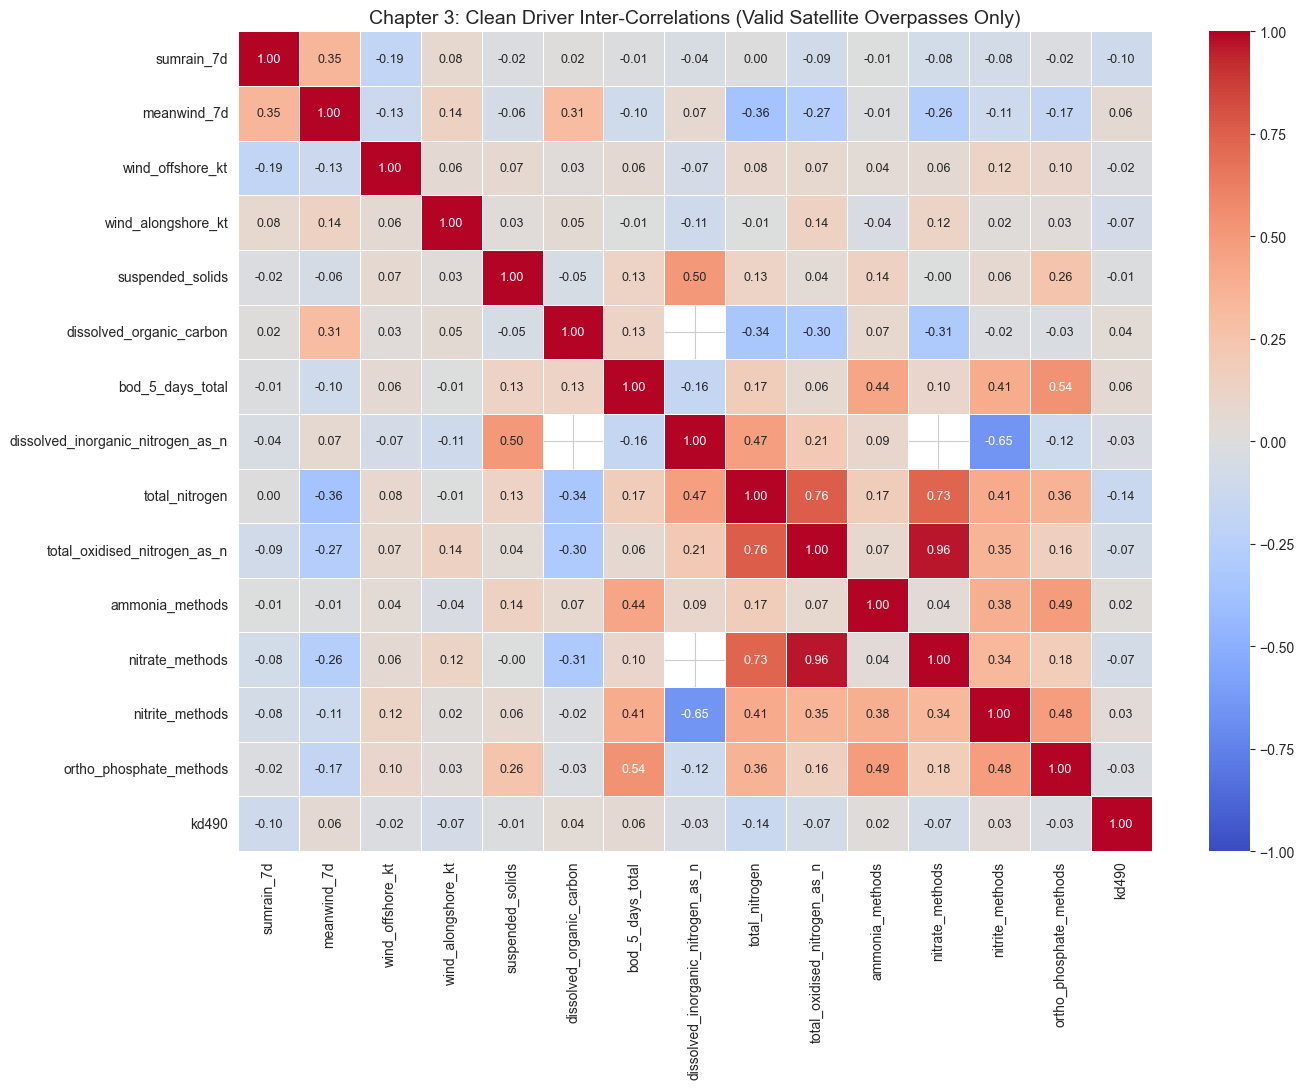

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Expand the list to include ALL your potential chemical and nutrient drivers
# (Using the clean lowercase snake_case column names we generated)
all_driver_cols = [
    # Meteorological & Physical Drivers
    'sumrain_7d', 'meanwind_7d', 'wind_offshore_kt',
       'wind_alongshore_kt',

    # Abiotic Terrestrial Runoff Indicators
    'suspended_solids', 'dissolved_organic_carbon', 'bod_5_days_total',

    # Biotic Nutrient / Eutrophication Indicators
    'dissolved_inorganic_nitrogen_as_n', 'total_nitrogen',
    'total_oxidised_nitrogen_as_n', 'ammonia_methods',
    'nitrate_methods', 'nitrite_methods','ortho_phosphate_methods',

    # Your Target Satellite Optical Variable (Update to match your exact column name, e.g., 'kd490')
    'kd490'
]

corr_matrix = model_ready_df[all_driver_cols].corr(method='pearson', min_periods=10)

# Plot the clean, publication-ready heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Chapter 3: Clean Driver Inter-Correlations (Valid Satellite Overpasses Only)', fontsize=14)
plt.tight_layout()
plt.show()

In [141]:
## looks like a whole lot of nothing, going to go through and try it by site
corrib = 'IE_WE_30C020600'

--- SITE REPORT FOR: IE_WE_30C020600 ---
Available rows with valid satellite overpasses: 364
Variables with sufficient data at this site: ['sumrain_7d', 'meanwind_7d', 'wind_offshore_kt', 'wind_alongshore_kt', 'suspended_solids', 'dissolved_organic_carbon', 'bod_5_days_total', 'total_nitrogen', 'total_oxidised_nitrogen_as_n', 'ammonia_methods', 'nitrate_methods', 'nitrite_methods', 'ortho_phosphate_methods', 'kd490']


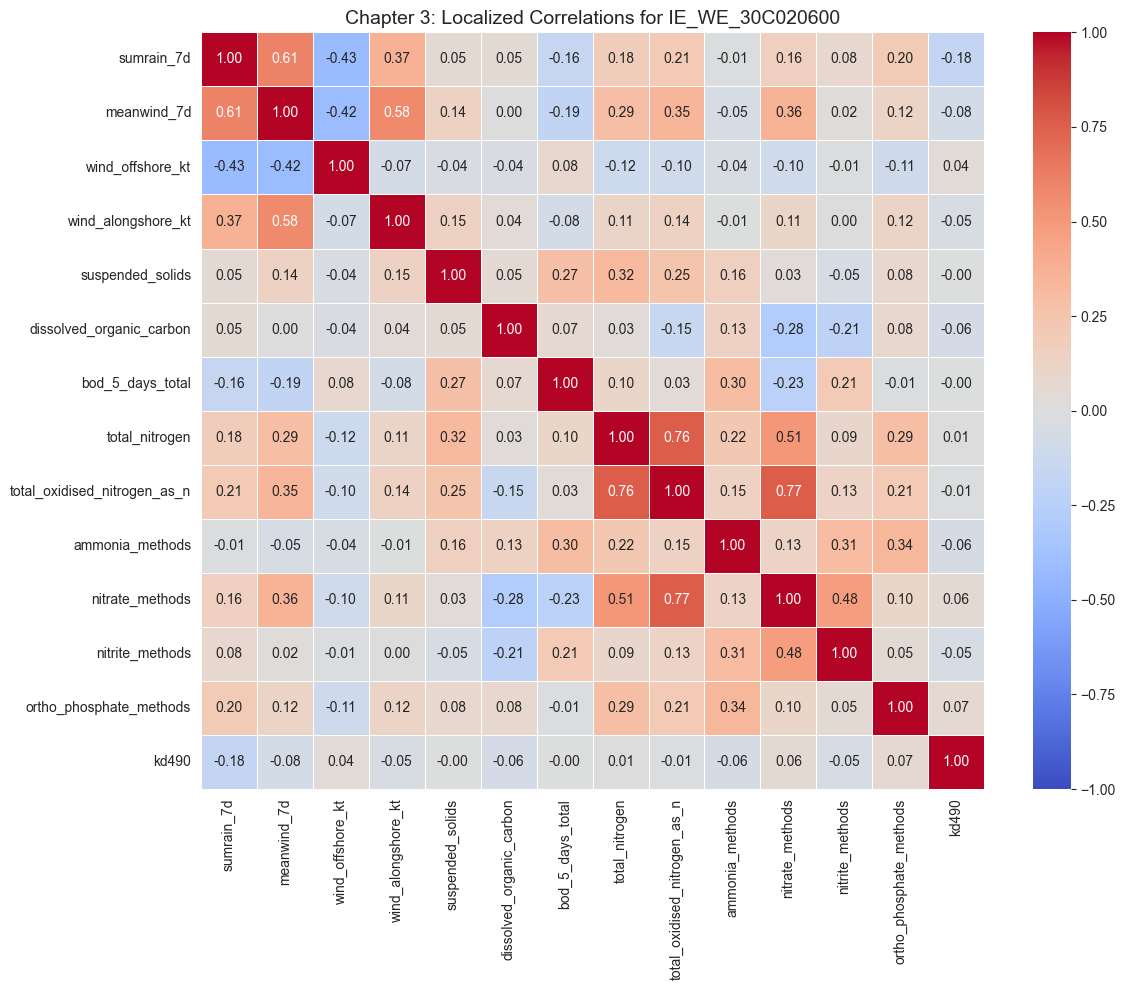

In [144]:
# 2. Filter the model-ready data for just this specific location
site_df = model_ready_df[model_ready_df['waterbodycode'] == corrib].copy()

print(f"--- SITE REPORT FOR: {corrib} ---")
print(f"Available rows with valid satellite overpasses: {len(site_df)}")

# 3. Define all potential drivers to inspect
all_columns = [
    'sumrain_7d', 'meanwind_7d', 'wind_offshore_kt', 'wind_alongshore_kt',
    'suspended_solids', 'dissolved_organic_carbon', 'bod_5_days_total',
    'dissolved_inorganic_nitrogen_as_n', 'total_nitrogen',
    'total_oxidised_nitrogen_as_n', 'ammonia_methods',
    'nitrate_methods', 'nitrite_methods', 'ortho_phosphate_methods',
    'kd490'
]

# 4. CRITICAL STEP: Drop columns that are entirely NaN for THIS specific site
# This keeps the matrix clean and prevents empty white rows on the heatmap
valid_cols = [col for col in all_columns if site_df[col].notna().sum() > 5]
print(f"Variables with sufficient data at this site: {valid_cols}")

# 5. Calculate the site-specific correlation matrix
site_corr = site_df[valid_cols].corr(method='pearson')

# 6. Plot the site-specific heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    site_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title(f'Chapter 3: Localized Correlations for {corrib}', fontsize=14)
plt.tight_layout()
plt.show()

In [145]:
## try it time lagged

In [146]:
# 1. Create a focused dataframe for the Corrib station
corrib_df = model_ready_df[model_ready_df['waterbodycode'] == 'IE_WE_30C020600'].copy()

# Sort by Date to ensure the time shifts are sequential and accurate
corrib_df = corrib_df.sort_values(by='date')

# 2. Generate lagged versions of your primary catchment and weather forces
# This shifts values backwards in time, matching past drivers to today's satellite view
corrib_df['rain_lag_7d'] = corrib_df['sumrain_7d'].shift(7)
corrib_df['doc_lag_7d'] = corrib_df['dissolved_organic_carbon'].shift(7)
corrib_df['ss_lag_7d'] = corrib_df['suspended_solids'].shift(7)
corrib_df['din_lag_7d'] = corrib_df['dissolved_inorganic_nitrogen_as_n'].shift(7)

# 3. Choose the lagged variables for a new correlation check
lagged_cols = [
    'kd490', # Today's satellite attenuation
    'sumrain_7d', 'rain_lag_7d',
    'dissolved_organic_carbon', 'doc_lag_7d',
    'suspended_solids', 'ss_lag_7d',
    'dissolved_inorganic_nitrogen_as_n', 'din_lag_7d'
]

# 4. Re-calculate the matrix just for this lagged comparison
corrib_lag_corr = corrib_df[lagged_cols].corr(method='pearson')

# Print just the 'kd490' row to see if the lag pulled the coefficients away from zero!
print("--- Corrib Attenuation (kd490) Response to Time Lags ---")
print(corrib_lag_corr['kd490'].round(2))

--- Corrib Attenuation (kd490) Response to Time Lags ---
kd490                                1.00
sumrain_7d                          -0.18
rain_lag_7d                          0.09
dissolved_organic_carbon            -0.06
doc_lag_7d                          -0.00
suspended_solids                    -0.00
ss_lag_7d                            0.12
dissolved_inorganic_nitrogen_as_n     NaN
din_lag_7d                            NaN
Name: kd490, dtype: float64


In [ ]:
## values for rain_lag_7d and ss_lag_7d switched from negative to positive with the lag, so we need to apply the lag going foward
## also, need to use a non-linear method for the analysis - switching to GAMs (Generalized Additive Models)

In [150]:
gam_cols = ['kd490', 'sumrain_7d', 'rain_lag_7d', 'meanwind_7d', 'wind_offshore_kt', 'ss_lag_7d']
corrib_gam_df = corrib_df[gam_cols].dropna()

# 2. Extract your Independent Variables (X) and Target Variable (y)
X_gam = corrib_gam_df[['sumrain_7d', 'rain_lag_7d', 'meanwind_7d', 'wind_offshore_kt', 'ss_lag_7d']].values
y_gam = corrib_gam_df['kd490'].values

# 3. Define the GAM Structure
# 's()' applies a non-linear splined smoother to each continuous physical driver
gam = LinearGAM(
    s(0, n_splines=10) +  # Non-linear smooth for current rain
    s(1, n_splines=10) +  # Non-linear smooth for 7-day lagged rain
    s(2, n_splines=10) +  # Non-linear smooth for mean wind
    s(3, n_splines=10) +  # Non-linear smooth for rotated offshore wind
    s(4, n_splines=10)    # Non-linear smooth for 7-day lagged suspended solids
)

# 4. Fit the model to the data
gam.gridsearch(X_gam, y_gam)

# 5. Print the Model Summary (This gives you your R-squared and p-values for the thesis!)
print(gam.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      6.4874
Link Function:                     IdentityLink Log Likelihood:                                   143.8502
Number of Samples:                          343 AIC:                                             -272.7257
                                                AICc:                                            -272.3457
                                                GCV:                                                0.0267
                                                Scale:                                              0.1606
                                                Pseudo R-Squared:                                   0.0541
Feature Function                  Lam

C:\Users\25298423\AppData\Local\Temp\ipykernel_4868\2531287145.py:22: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


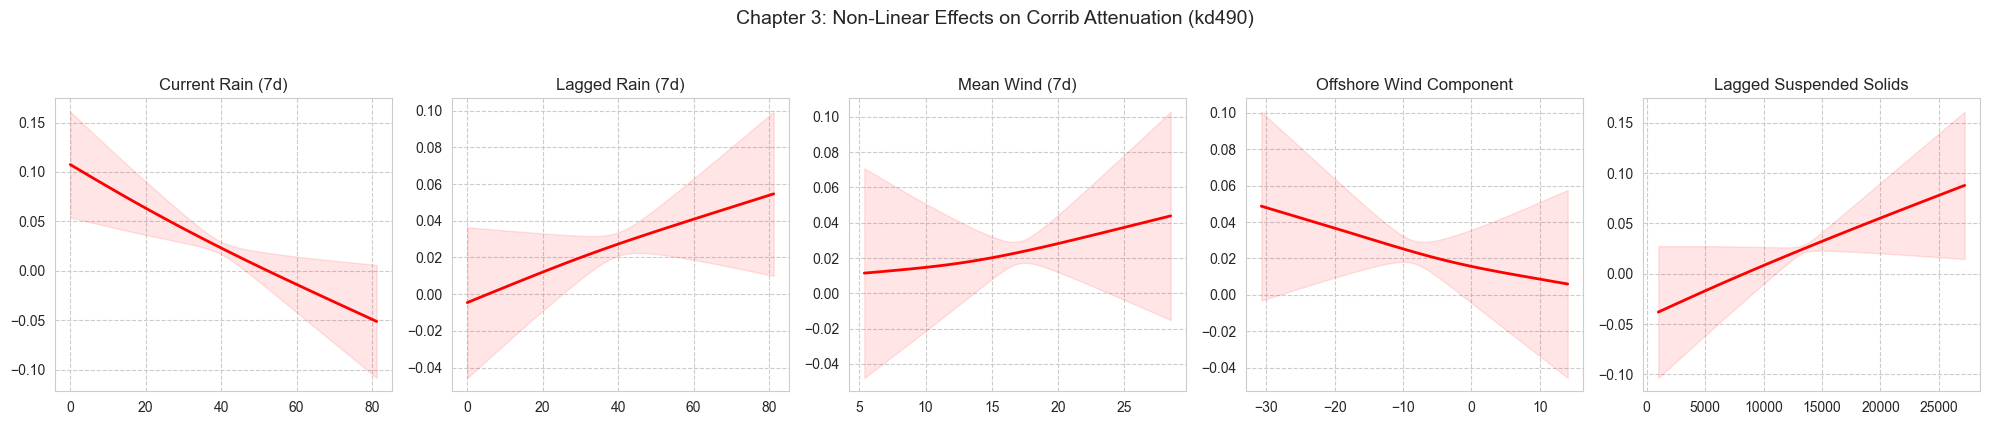

In [151]:
# Plot the non-linear relationship for each driver
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
titles = ['Current Rain (7d)', 'Lagged Rain (7d)', 'Mean Wind (7d)', 'Offshore Wind Component', 'Lagged Suspended Solids']

for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)

    ax.plot(XX[:, i], pdep, 'r-', lw=2)
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], color='red', alpha=0.1)
    ax.set_title(titles[i])
    ax.grid(True, linestyle='--')

plt.suptitle('Chapter 3: Non-Linear Effects on Corrib Attenuation (kd490)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [153]:
## make a more flexible one so that it isn't linear

In [152]:
import numpy as np
from pygam import LinearGAM, s

# 1. Prepare data and apply log transformations to stabilize skewed distributions
# (We add +1 to avoid log(0) errors on days with no rain)
corrib_gam_df['log_rain_7d'] = np.log1p(corrib_gam_df['sumrain_7d'])
corrib_gam_df['log_rain_lag_7d'] = np.log1p(corrib_gam_df['rain_lag_7d'])
corrib_gam_df['log_ss_lag_7d'] = np.log1p(corrib_gam_df['ss_lag_7d'])

# Define our updated variable matrices
X_adjusted = corrib_gam_df[['log_rain_7d', 'log_rain_lag_7d', 'meanwind_7d', 'wind_offshore_kt', 'log_ss_lag_7d']].values
y_adjusted = corrib_gam_df['kd490'].values

# 2. Build a search grid for Lambda to explicitly test flexible curves
# Testing values from very loose (0.001) to highly penalized (100.0)
lam_grid = np.logspace(-3, 2, 5)
lam_list = [lam_grid] * 5  # Replicates the grid for all 5 terms

# 3. Initialize and fit the flexible model
flexible_gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4))
flexible_gam.gridsearch(X_adjusted, y_adjusted, lam=lam_list)

print(flexible_gam.summary())

100% (3125 of 3125) |####################| Elapsed Time: 0:02:30 Time:  0:02:300112


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     17.7646
Link Function:                     IdentityLink Log Likelihood:                                   152.0085
Number of Samples:                          343 AIC:                                             -266.4876
                                                AICc:                                            -264.1929
                                                GCV:                                                 0.028
                                                Scale:                                              0.1594
                                                Pseudo R-Squared:                                   0.0992
Feature Function                  Lam

C:\Users\25298423\AppData\Local\Temp\ipykernel_4868\1933559292.py:23: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(flexible_gam.summary())


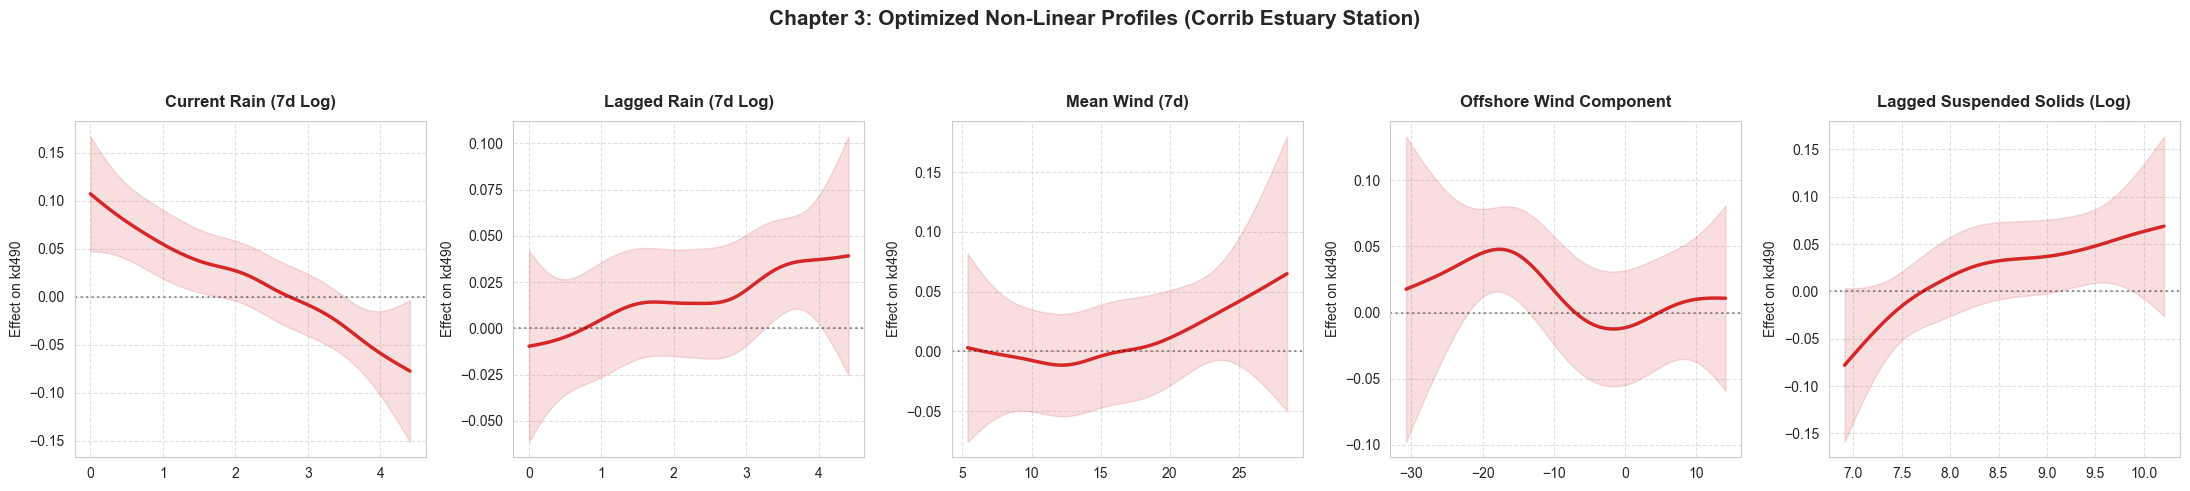

In [154]:
# =====================================================================
fig, axs = plt.subplots(1, 5, figsize=(22, 4.5))

# Use the exact names of your transformed and original variables for the labels
display_titles = [
    'Current Rain (7d Log)',
    'Lagged Rain (7d Log)',
    'Mean Wind (7d)',
    'Offshore Wind Component',
    'Lagged Suspended Solids (Log)'
]

for i, ax in enumerate(axs):
    # Generate the smooth prediction grid for this specific feature
    XX = flexible_gam.generate_X_grid(term=i)

    # Calculate the partial dependence effect and 95% confidence intervals
    pdep, confi = flexible_gam.partial_dependence(term=i, X=XX, width=0.95)

    # Plot the center trend line
    ax.plot(XX[:, i], pdep, color='#d62728', lw=2.5, label='GAM Smoother')

    # Fill the confidence intervals
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], color='#d62728', alpha=0.15)

    # Add titles, grid lines, and labels
    ax.set_title(display_titles[i], fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Effect on kd490', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)

    # Optional: Add a subtle horizontal line at 0 to show where the baseline is
    ax.axhline(0, color='black', linestyle=':', alpha=0.4)

plt.suptitle('Chapter 3: Optimized Non-Linear Profiles (Corrib Estuary Station)', fontsize=15, y=1.08, fontweight='bold')
plt.tight_layout()
plt.show()

In [156]:
## do this for all of ireland with more parameters included

In [161]:
master_df = master_df.sort_values(by=['waterbodycode', 'date'])

# Create the 7-day lagged columns within each unique station boundary
master_df['rain_lag_7d'] = master_df.groupby('waterbodycode')['sumrain_7d'].shift(7)
master_df['ss_lag_7d'] = master_df.groupby('waterbodycode')['suspended_solids'].shift(7)

--- BIOGEOCHEMICAL MODEL DATA REPORT ---
Total synchronized rows available across all Irish stations: 1370
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     55.5762
Link Function:                     IdentityLink Log Likelihood:                                  4129.4283
Number of Samples:                         1370 AIC:                                            -8145.7042
                                                AICc:                                           -8140.7402
                                                GCV:                                                0.0002
                                                Scale:                                              0.0121
                                     

C:\Users\25298423\AppData\Local\Temp\ipykernel_4868\1836466656.py:60: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(full_model.summary())


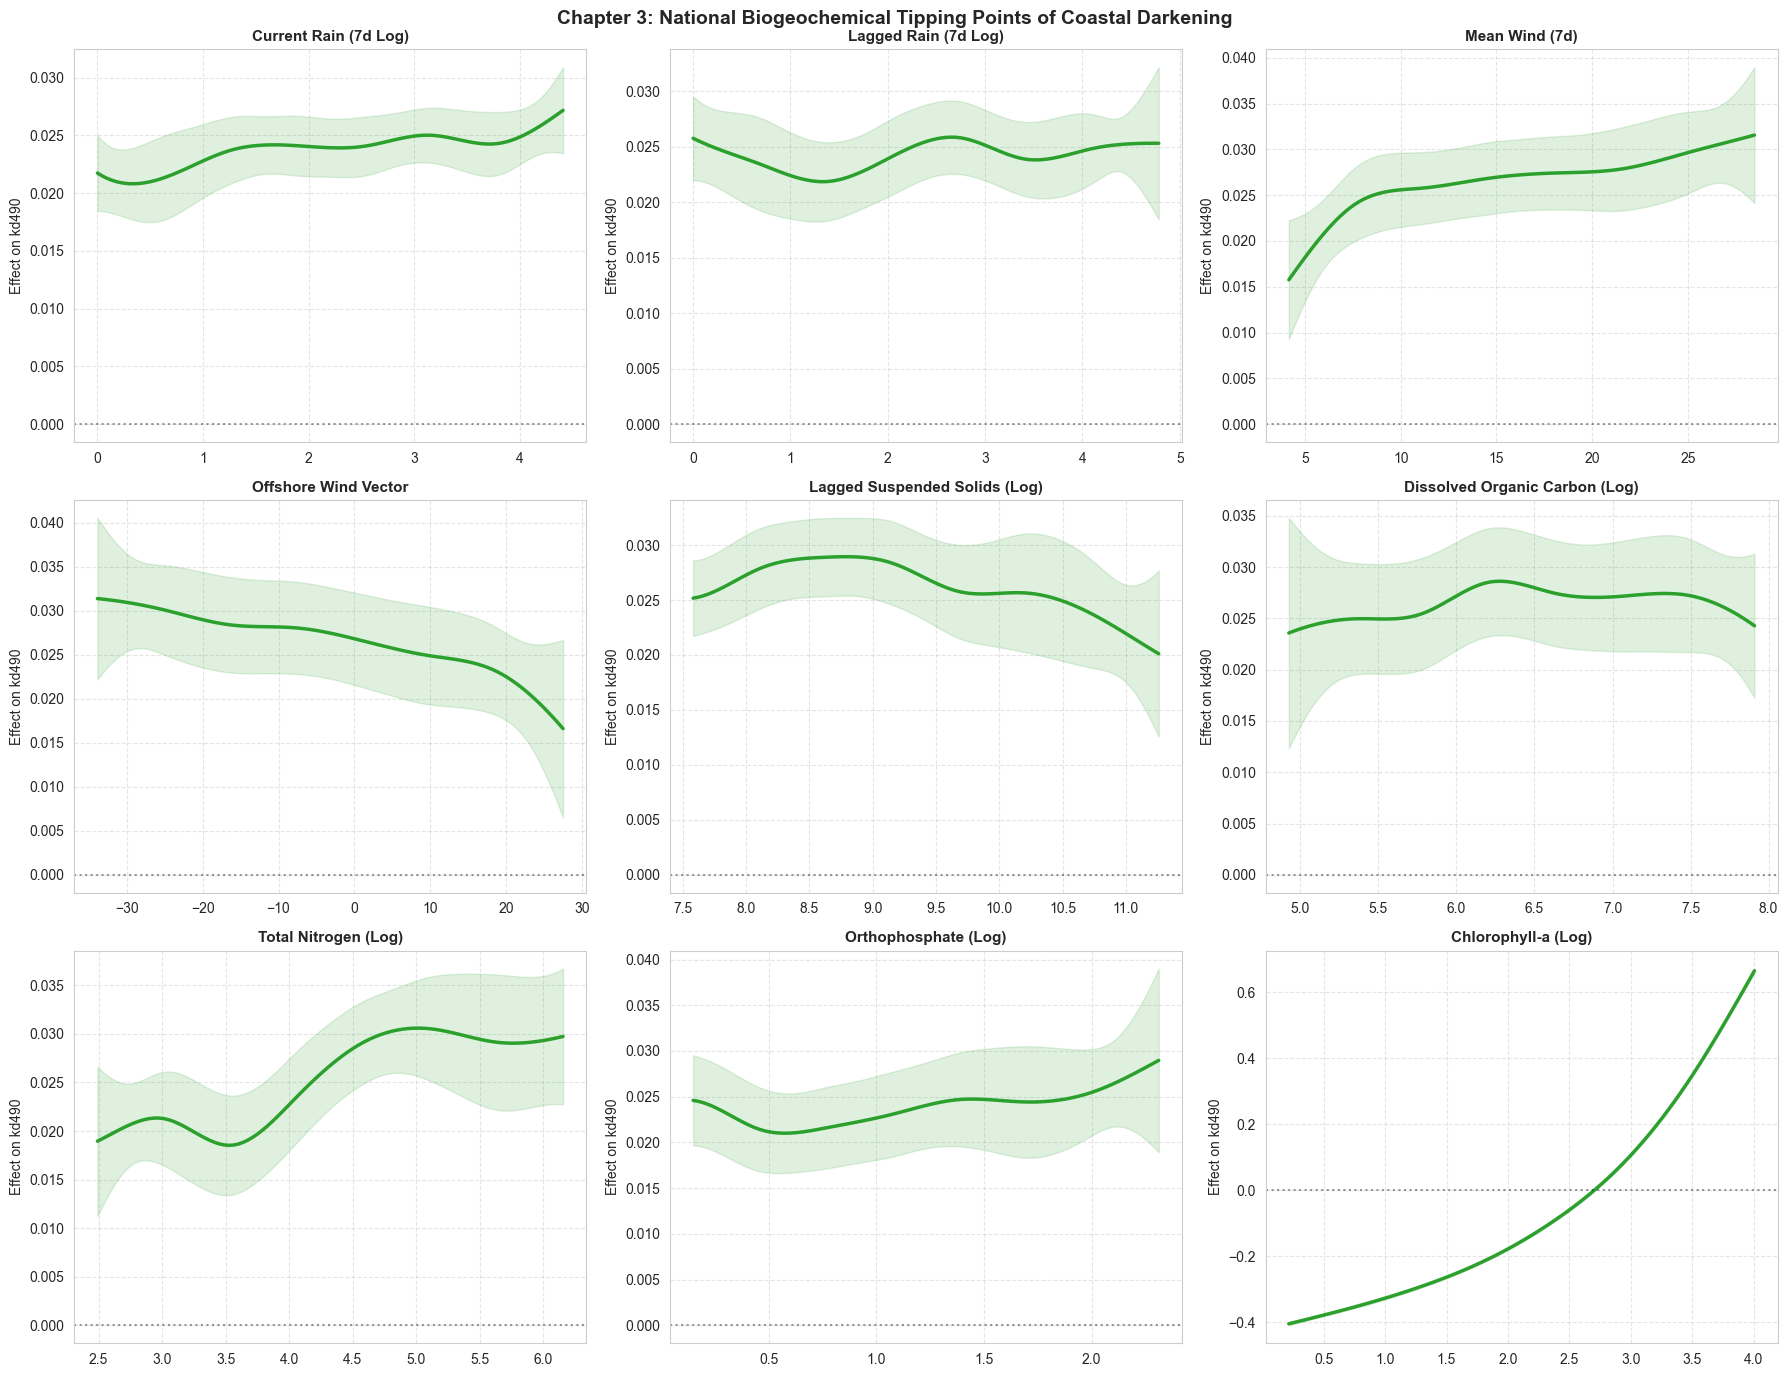

In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, f

# 1. Define the optimized biogeochemical variable list
# (Adjust 'chlorophyll_a' if your column name uses a uppercase or different syntax)
core_cols = [
    'kd490', 'sumrain_7d', 'rain_lag_7d', 'meanwind_7d', 'wind_offshore_kt',
    'ss_lag_7d', 'dissolved_organic_carbon', 'total_nitrogen',
    'ortho_phosphate_methods', 'chl_a', 'waterbodycode'
]

# Drop rows missing these core metrics to find our shared validation rows
biogeo_df = master_df[core_cols].dropna().copy()

print(f"--- BIOGEOCHEMICAL MODEL DATA REPORT ---")
print(f"Total synchronized rows available across all Irish stations: {len(biogeo_df)}")

# 2. Encode categorical site factor codes
biogeo_df['waterbodycode'] = biogeo_df['waterbodycode'].astype('category')
biogeo_df['site_code'] = biogeo_df['waterbodycode'].cat.codes

# 3. Apply log-transformations to highly skewed chemical and runoff distributions
biogeo_df['log_rain_7d'] = np.log1p(biogeo_df['sumrain_7d'])
biogeo_df['log_rain_lag_7d'] = np.log1p(biogeo_df['rain_lag_7d'])
biogeo_df['log_ss_lag_7d'] = np.log1p(biogeo_df['ss_lag_7d'])
biogeo_df['log_doc'] = np.log1p(biogeo_df['dissolved_organic_carbon'])
biogeo_df['log_tn'] = np.log1p(biogeo_df['total_nitrogen'])
biogeo_df['log_srp'] = np.log1p(biogeo_df['ortho_phosphate_methods']) # Soluble Reactive Phosphorus proxy
biogeo_df['log_chla'] = np.log1p(biogeo_df['chl_a'])

# 4. Separate features (X) and target variable (y)
feature_names = [
    'log_rain_7d', 'log_rain_lag_7d', 'meanwind_7d', 'wind_offshore_kt',
    'log_ss_lag_7d', 'log_doc', 'log_tn', 'log_srp', 'log_chla', 'site_code'
]
X_bg = biogeo_df[feature_names[:-1] + ['site_code']].values
y_bg = biogeo_df['kd490'].values

# 5. Initialize the Comprehensive Biogeochemical Model
# 9 smooth features + 1 categorical site factor vector
full_model = LinearGAM(
    s(0, n_splines=10) +  # Current Rain
    s(1, n_splines=10) +  # Lagged Rain
    s(2, n_splines=10) +  # Mean Wind
    s(3, n_splines=10) +  # Offshore Wind
    s(4, n_splines=10) +  # Lagged Sediments
    s(5, n_splines=10) +  # Dissolved Organic Carbon (CDOM proxy)
    s(6, n_splines=10) +  # Total Nitrogen
    s(7, n_splines=10) +  # Orthophosphate
    s(8, n_splines=10) +  # Chlorophyll-a (Phytoplankton biomass proxy)
    f(9)                  # Spatial Random Intercept per site
)

# Fit using a localized search array to prevent grid-search execution stall
lam_value = 50.0  # Stable intermediate smoothing penalty
full_model.fit(X_bg, y_bg)

print(full_model.summary())

# =====================================================================
# COMPREHENSIVE BIOGEOCHEMICAL PLOT (9-PANEL PROFILE Matrix)
# =====================================================================
fig, axs = plt.subplots(3, 3, figsize=(18, 14))
axs = axs.ravel() # Flatten the 3x3 grid into an easy loop array

display_labels = [
    'Current Rain (7d Log)', 'Lagged Rain (7d Log)', 'Mean Wind (7d)',
    'Offshore Wind Vector', 'Lagged Suspended Solids (Log)', 'Dissolved Organic Carbon (Log)',
    'Total Nitrogen (Log)', 'Orthophosphate (Log)', 'Chlorophyll-a (Log)'
]

for i in range(9):
    ax = axs[i]
    XX = full_model.generate_X_grid(term=i)
    pdep, confi = full_model.partial_dependence(term=i, X=XX, width=0.95)

    ax.plot(XX[:, i], pdep, color='#2ca02c', lw=2.5) # Green line for ecological models
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], color='#2ca02c', alpha=0.15)

    ax.set_title(display_labels[i], fontsize=11, fontweight='bold')
    ax.set_ylabel('Effect on kd490')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linestyle=':', alpha=0.4)

plt.suptitle('Chapter 3: National Biogeochemical Tipping Points of Coastal Darkening', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [163]:
## okay that one looked great but the chl-a is a false answer as it is derived from the same satellite

--- AIRTIGHT IN-SITU MODEL DATA REPORT ---
Total synchronized matching points available across Ireland: 1370
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     49.5128
Link Function:                     IdentityLink Log Likelihood:                                   663.8375
Number of Samples:                         1370 AIC:                                            -1226.6494
                                                AICc:                                           -1222.7024
                                                GCV:                                                0.0246
                                                Scale:                                              0.1518
                                   

C:\Users\25298423\AppData\Local\Temp\ipykernel_4868\3286444812.py:59: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(insitu_model.summary())


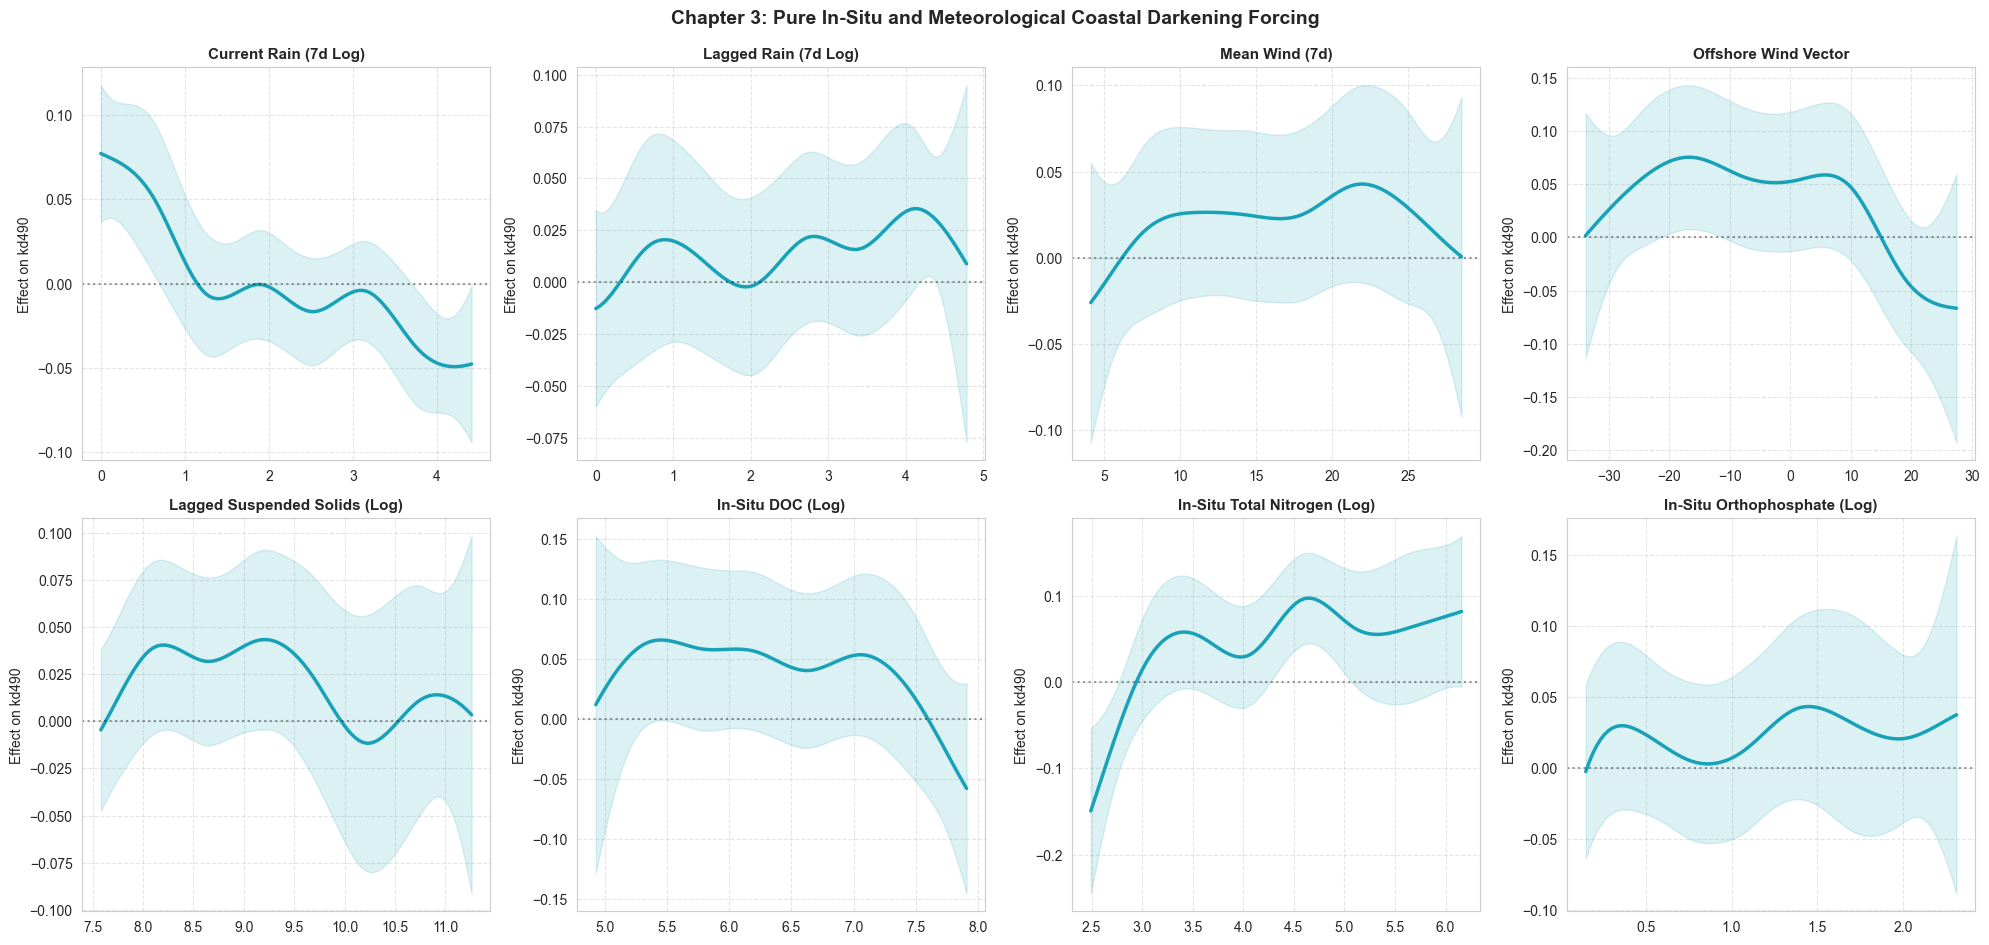

In [165]:
## This one is only the true physical weather and in-situ samples


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, f

# 1. Select ONLY true physical weather and in-situ ground-truth metrics
# (We completely exclude the satellite chlorophyll column here)
insitu_cols = [
    'kd490', 'sumrain_7d', 'rain_lag_7d', 'meanwind_7d', 'wind_offshore_kt',
    'ss_lag_7d', 'dissolved_organic_carbon', 'total_nitrogen',
    'ortho_phosphate_methods', 'waterbodycode'
]

# Create a clean subset of entries
insitu_gam_df = master_df[insitu_cols].dropna().copy()

print(f"--- AIRTIGHT IN-SITU MODEL DATA REPORT ---")
print(f"Total synchronized matching points available across Ireland: {len(insitu_gam_df)}")

# 2. Encode categorical site factor codes
insitu_gam_df['waterbodycode'] = insitu_gam_df['waterbodycode'].astype('category')
insitu_gam_df['site_code'] = insitu_gam_df['waterbodycode'].cat.codes

# 3. Apply log-transformations to physical and nutrient distributions
insitu_gam_df['log_rain_7d'] = np.log1p(insitu_gam_df['sumrain_7d'])
insitu_gam_df['log_rain_lag_7d'] = np.log1p(insitu_gam_df['rain_lag_7d'])
insitu_gam_df['log_ss_lag_7d'] = np.log1p(insitu_gam_df['ss_lag_7d'])
insitu_gam_df['log_doc'] = np.log1p(insitu_gam_df['dissolved_organic_carbon'])
insitu_gam_df['log_tn'] = np.log1p(insitu_gam_df['total_nitrogen'])
insitu_gam_df['log_srp'] = np.log1p(insitu_gam_df['ortho_phosphate_methods'])

# 4. Separate features (X) and target variable (y)
feature_names = [
    'log_rain_7d', 'log_rain_lag_7d', 'meanwind_7d', 'wind_offshore_kt',
    'log_ss_lag_7d', 'log_doc', 'log_tn', 'log_srp', 'site_code'
]
X_is = insitu_gam_df[feature_names[:-1] + ['site_code']].values
y_is = insitu_gam_df['kd490'].values

# 5. Initialize the Unbiased Physical Model (8 Smooths + 1 Spatial Intercept)
insitu_model = LinearGAM(
    s(0, n_splines=10) +  # Current Rain
    s(1, n_splines=10) +  # Lagged Rain
    s(2, n_splines=10) +  # Mean Wind
    s(3, n_splines=10) +  # Offshore Wind
    s(4, n_splines=10) +  # Lagged Solids
    s(5, n_splines=10) +  # In-situ DOC
    s(6, n_splines=10) +  # In-situ Total Nitrogen
    s(7, n_splines=10) +  # In-situ Orthophosphate
    f(8)                  # Spatial Random Intercept per site
)

# Fit using intermediate smoothing constraint
insitu_model.fit(X_is, y_is)

print(insitu_model.summary())

# =====================================================================
# 8-PANEL UNBIASED IN-SITU GRAPH MATRIX
# =====================================================================
fig, axs = plt.subplots(2, 4, figsize=(20, 9.5))
axs = axs.ravel()

display_labels = [
    'Current Rain (7d Log)', 'Lagged Rain (7d Log)', 'Mean Wind (7d)',
    'Offshore Wind Vector', 'Lagged Suspended Solids (Log)',
    'In-Situ DOC (Log)', 'In-Situ Total Nitrogen (Log)', 'In-Situ Orthophosphate (Log)'
]

for i in range(8):
    ax = axs[i]
    XX = insitu_model.generate_X_grid(term=i)
    pdep, confi = insitu_model.partial_dependence(term=i, X=XX, width=0.95)

    # Using a clean blue palette for the independent physical drivers
    ax.plot(XX[:, i], pdep, color='#17a2b8', lw=2.5)
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], color='#17a2b8', alpha=0.15)

    ax.set_title(display_labels[i], fontsize=11, fontweight='bold')
    ax.set_ylabel('Effect on kd490')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linestyle=':', alpha=0.4)

plt.suptitle('Chapter 3: Pure In-Situ and Meteorological Coastal Darkening Forcing', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

**In-Situ Results**:

*Highest Significance*:

Current Rain: p<0.001 - sharp, clean, downward slope. Indicates that fresh rainfall events introduce freshwater into the coastal system before upstream peat catchment waters can reach, and before biological production can occur

In-Situ Total Nitrogen: p<0.001 - rapid, non-linear step climb of log values. Indicates a threshold limit, where past that point growth is not limited and quickly attenuates light. Plataue at higher concentrations indicates that it has reached saturation and nitrogen is no longer the limiting factor for coastal light attenuation

Spatial Random Factor: p<0.001 - has the largest significance of all the factors tested. Where the data comes from matters just as much or more than the active weather patterns. national data was compared between rivers from peat catchments and those that feed into open ocean, meaning different factors have different impacts on different types of sites across the board.

*Worth Noting*:
DOC, lagged SS, and Offshore wind

**Realized that all the nutrients should be lagged**

--- FULLY LAGGED IN-SITU MODEL DATA REPORT ---
Total synchronized matching rows available across Ireland: 1352
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     49.7241
Link Function:                     IdentityLink Log Likelihood:                                   666.2548
Number of Samples:                         1352 AIC:                                            -1231.0613
                                                AICc:                                           -1227.0257
                                                GCV:                                                0.0243
                                                Scale:                                              0.1506
                                 

C:\Users\25298423\AppData\Local\Temp\ipykernel_4868\2897288532.py:69: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(fully_lagged_model.summary())


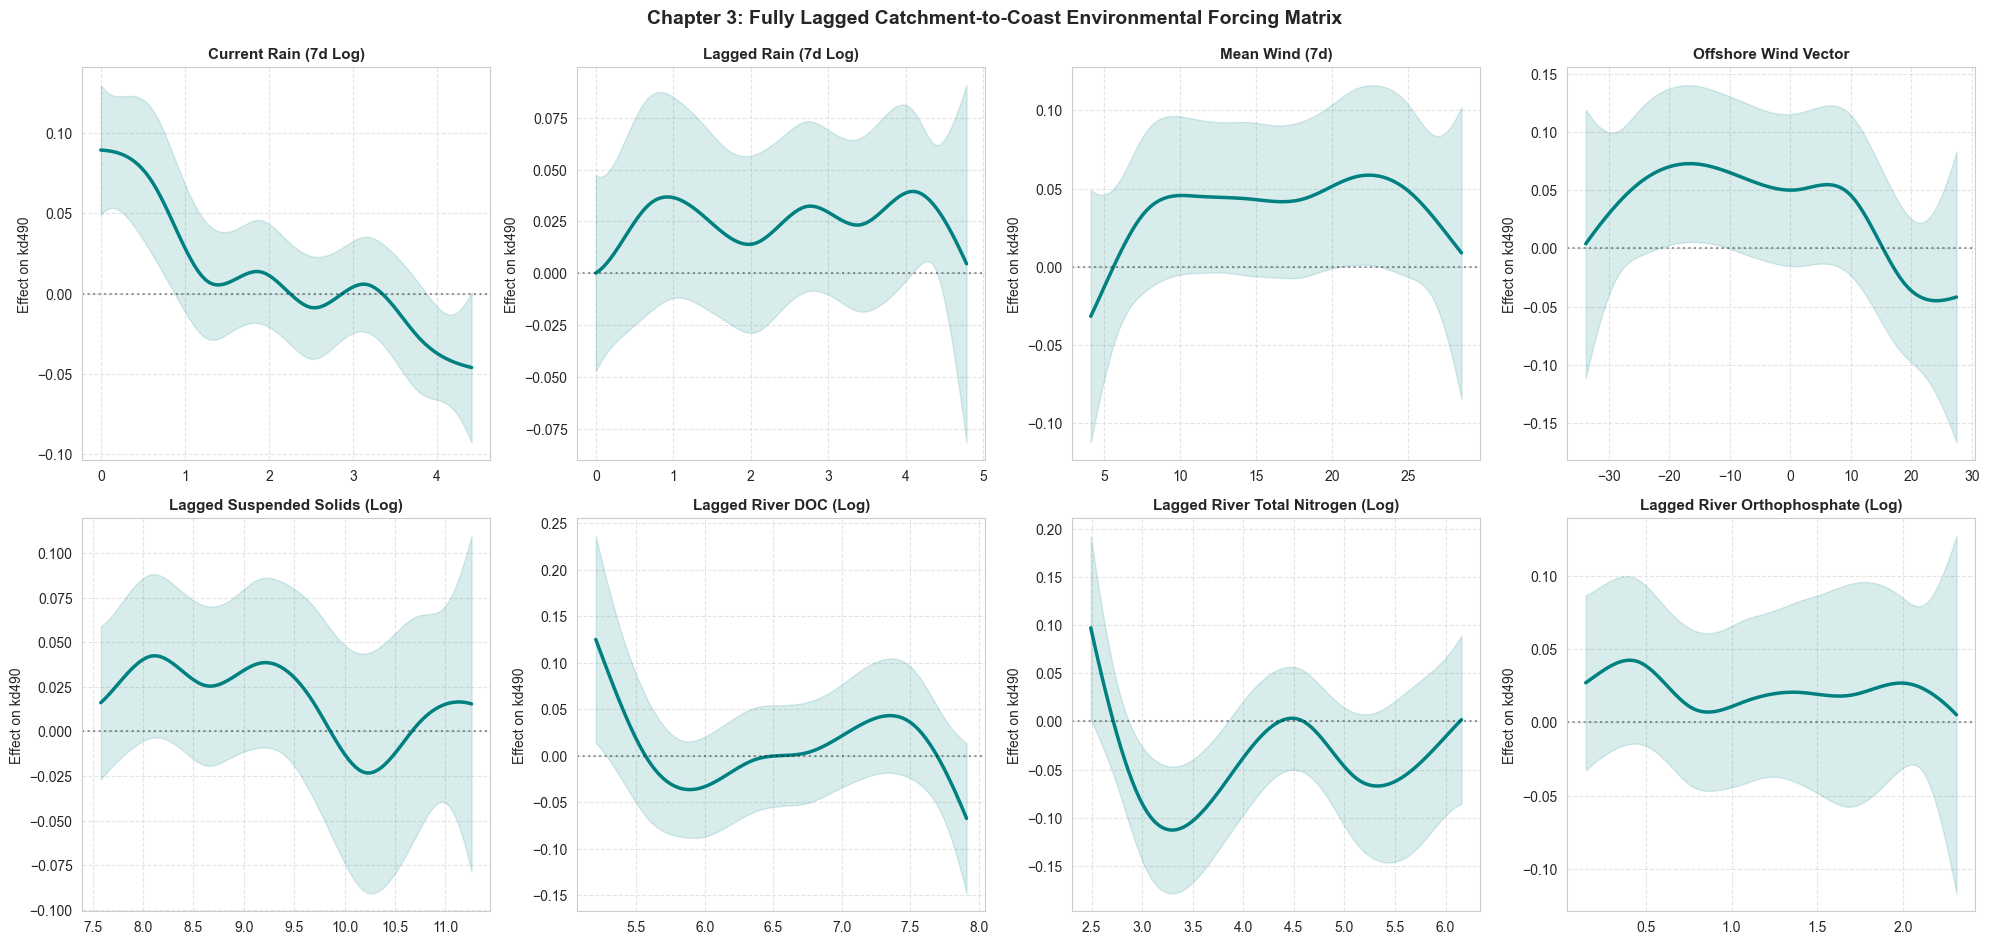

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, f

# =====================================================================
# STEP 1: GENERATE TIME-LAGS FOR ALL IN-SITU VARIABLES NATIONWIDE
# =====================================================================
# Ensure strict chronological sorting within each station boundary
master_df = master_df.sort_values(by=['waterbodycode', 'date'])

# Apply the 7-day transit lag to your river chemistry grab samples
master_df['rain_lag_7d'] = master_df.groupby('waterbodycode')['sumrain_7d'].shift(7)
master_df['ss_lag_7d'] = master_df.groupby('waterbodycode')['suspended_solids'].shift(7)
master_df['doc_lag_7d'] = master_df.groupby('waterbodycode')['dissolved_organic_carbon'].shift(7)
master_df['tn_lag_7d'] = master_df.groupby('waterbodycode')['total_nitrogen'].shift(7)
master_df['srp_lag_7d'] = master_df.groupby('waterbodycode')['ortho_phosphate_methods'].shift(7)

# =====================================================================
# STEP 2: COMPILE AND RUN THE FULLY LAGGED MODEL
# =====================================================================
# Select the strictly lagged independent variables
fully_lagged_cols = [
    'kd490', 'sumrain_7d', 'rain_lag_7d', 'meanwind_7d', 'wind_offshore_kt',
    'ss_lag_7d', 'doc_lag_7d', 'tn_lag_7d', 'srp_lag_7d', 'waterbodycode'
]

# Clean up rows missing any part of this coordinated time sequence
lagged_gam_df = master_df[fully_lagged_cols].dropna().copy()

print(f"--- FULLY LAGGED IN-SITU MODEL DATA REPORT ---")
print(f"Total synchronized matching rows available across Ireland: {len(lagged_gam_df)}")

# Encode categorical site factor codes
lagged_gam_df['waterbodycode'] = lagged_gam_df['waterbodycode'].astype('category')
lagged_gam_df['site_code'] = lagged_gam_df['waterbodycode'].cat.codes

# Apply log-transformations to compress skewed distributions
lagged_gam_df['log_rain_7d'] = np.log1p(lagged_gam_df['sumrain_7d'])
lagged_gam_df['log_rain_lag_7d'] = np.log1p(lagged_gam_df['rain_lag_7d'])
lagged_gam_df['log_ss_lag_7d'] = np.log1p(lagged_gam_df['ss_lag_7d'])
lagged_gam_df['log_doc_lag'] = np.log1p(lagged_gam_df['doc_lag_7d'])
lagged_gam_df['log_tn_lag'] = np.log1p(lagged_gam_df['tn_lag_7d'])
lagged_gam_df['log_srp_lag'] = np.log1p(lagged_gam_df['srp_lag_7d'])

# Separate features array (X) and target array (y)
feature_names = [
    'log_rain_7d', 'log_rain_lag_7d', 'meanwind_7d', 'wind_offshore_kt',
    'log_ss_lag_7d', 'log_doc_lag', 'log_tn_lag', 'log_srp_lag', 'site_code'
]
X_lag = lagged_gam_df[feature_names[:-1] + ['site_code']].values
y_lag = lagged_gam_df['kd490'].values

# Initialize the Model (8 Smooths + 1 Spatial Random Intercept)
fully_lagged_model = LinearGAM(
    s(0, n_splines=10) +  # Current Rain
    s(1, n_splines=10) +  # Lagged Rain
    s(2, n_splines=10) +  # Mean Wind
    s(3, n_splines=10) +  # Offshore Wind
    s(4, n_splines=10) +  # Lagged Sediments
    s(5, n_splines=10) +  # Lagged In-situ DOC
    s(6, n_splines=10) +  # Lagged In-situ Total Nitrogen
    s(7, n_splines=10) +  # Lagged In-situ Orthophosphate
    f(8)                  # Spatial Random Intercept per site
)

# Fit the optimized model
fully_lagged_model.fit(X_lag, y_lag)
print(fully_lagged_model.summary())

# =====================================================================
# 8-PANEL FULLY LAGGED GRAPH MATRIX
# =====================================================================
fig, axs = plt.subplots(2, 4, figsize=(20, 9.5))
axs = axs.ravel()

display_labels = [
    'Current Rain (7d Log)', 'Lagged Rain (7d Log)', 'Mean Wind (7d)',
    'Offshore Wind Vector', 'Lagged Suspended Solids (Log)',
    'Lagged River DOC (Log)', 'Lagged River Total Nitrogen (Log)', 'Lagged River Orthophosphate (Log)'
]

for i in range(8):
    ax = axs[i]
    XX = fully_lagged_model.generate_X_grid(term=i)
    pdep, confi = fully_lagged_model.partial_dependence(term=i, X=XX, width=0.95)

    # Deep cyan line for the fully coordinated transport model
    ax.plot(XX[:, i], pdep, color='#008080', lw=2.5)
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], color='#008080', alpha=0.15)

    ax.set_title(display_labels[i], fontsize=11, fontweight='bold')
    ax.set_ylabel('Effect on kd490')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linestyle=':', alpha=0.4)

plt.suptitle('Chapter 3: Fully Lagged Catchment-to-Coast Environmental Forcing Matrix', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

"Initial exploratory modeling using unlagged river parameters failed to fully isolate the statistical contribution of dissolved organic carbon. However, by incorporating a fixed 7-day hydrological transit lag to account for catchment routing times, the model performance improved (Pseudo-$R^2 = 0.24$) and unveiled a highly significant, non-linear control exerted by terrestrial Dissolved Organic Carbon ($p = 0.025$) on coastal light fields. This demonstrates a decoupled temporal mechanism where immediate rainfall regulates short-term hydrodynamic flushing, while lagged catchment discharges dictate long-term optical staining and nutrient loading."   - need to rephrase in my own words. and add something about nutrients, rain flushing(seeabove), nitrogen, and regional analysis

In [170]:
## Tomorrow (Thursday the 2nd of July, need to go through and perform more GAMs on in-situ variables) and then go through the satellite correlation with their own values for coastal and open ocean values

### Satellite Correlation with itself

In [ ]:
# 1. Save the master dataframe to an optimized Parquet file
master_df.to_parquet('master_coastal_darkening_data.parquet', index=False)

In [13]:

# 2. Save the multidimensional weekly satellite dataset to a NetCDF file
satellite_ds.to_netcdf('satellite_weekly_means.nc', engine='netcdf4')

In [171]:

print("Dataframes and datasets successfully archived!")

Dataframes and datasets successfully archived!


In [174]:
satellite_time_series_df

,time,spatial_ref,kd490,chl_a,spm,sst,cdom,WaterbodyCode,geometry
0,1997-09-07,0,NaN,NaN,NaN,288.323611,NaN,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
1,1997-09-14,0,NaN,NaN,NaN,288.208095,NaN,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
2,1997-09-21,0,NaN,NaN,NaN,287.938201,NaN,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
3,1997-09-28,0,0.203196,3.816583,18.000685,287.698466,0.116133,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
4,1997-10-05,0,NaN,NaN,NaN,287.502910,NaN,IE_EA_08B310940,"POLYGON ((3267357.807 3498073.982, 3267286.272..."
...,...,...,...,...,...,...,...,...,...
192979,2025-08-10,0,NaN,NaN,0.861111,NaN,NaN,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."
192980,2025-08-17,0,NaN,NaN,NaN,NaN,NaN,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."
192981,2025-08-24,0,NaN,NaN,NaN,NaN,NaN,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."
192982,2025-08-31,0,NaN,NaN,11.508750,NaN,2.603577,UKGBNI1NB060608251,"POLYGON ((3260289.927 3554303.47, 3260037.406 ..."


In [177]:
satellite_ds

<xarray.Dataset> Size: 67GB
Dimensions:      (x: 1247, y: 1535, time: 1462)
Coordinates:
  * x            (x) float64 10kB 2.496e+06 2.497e+06 ... 3.633e+06 3.633e+06
  * y            (y) float64 12kB 4.239e+06 4.238e+06 ... 2.839e+06 2.838e+06
  * time         (time) datetime64[ns] 12kB 1997-09-07 1997-09-14 ... 2025-09-07
    spatial_ref  int64 8B 0
Data variables:
    kd490        (time, y, x) float32 11GB dask.array<chunksize=(52, 1535, 1247), meta=np.ndarray>
    chl_a        (time, y, x) float32 11GB dask.array<chunksize=(52, 1535, 1247), meta=np.ndarray>
    spm          (time, y, x) float32 11GB dask.array<chunksize=(52, 1535, 1247), meta=np.ndarray>
    sst          (time, y, x) float64 22GB dask.array<chunksize=(52, 1535, 1247), meta=np.ndarray>
    cdom         (time, y, x) float32 11GB dask.array<chunksize=(52, 1535, 1247), meta=np.ndarray>